In [49]:
# system imports
import os, re
import sys
import json
import math
from math import sqrt
from symbol import not_test

# data science
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# from matplotlib.patches import Ellipse
# import matplotlib.animation as animation
# from numpy.lib.utils import show_runtime
# import matplotlib.lines as mlines

# signal processing
from scipy import signal
from scipy.ndimage import label
from scipy.signal import savgol_filter

from scipy.stats import zscore
from scipy.interpolate import interp1d
# from scipy.integrate import trapz
# from scipy.signal import butter, filtfilt

# physionet data
# import wfdb
# from wfdb import processing

from biosppy.signals import ecg, hrv, ppg, acc, eda
from biosppy import inter_plotting
from scipy.interpolate import CubicSpline
from scipy.stats import zscore
import biosppy.signals.hrv as hrv

import seaborn as sns
import warnings

# import wfdb
import pywt
import math
from sklearn.metrics import mean_squared_error

import ipywidgets as widgets
from IPython.display import display
from sympy import false

from utils import *

warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=Warning)  # Suppress BioSPPy warnings

print("numpy version (should be < 2)")
np.version.version ## should be < 2

numpy version (should be < 2)


'1.26.4'

In [28]:
# path settings
project_path = os.path.join(os.getcwd(), os.pardir)
data_path = os.path.join(project_path, 'data')
output_path = os.path.join(project_path, 'output')

# style settings
sns.set(style='whitegrid', rc={'axes.facecolor': '#EFF2F7'})

# sample frequency for Bobbi sensor
settings = {}
settings['fs'] = 500

identifiers = "s1_SHE_T1,s1_SHE_T2,s1_SHE_T3,s1_HE_T4,s1_HE_T5,s1_HE_T6,s2_HE_T1,s2_HE_T2,s2_HE_T3,s2_SHE_T4,s2_SHE_T5,s2_SHE_T6,s2_SHE_T7,s3_SHE_T1,s3_SHE_T2,s3_SHE_T3,s3_HE_T4,s3_HE_T5,s3_HE_T6,s4_HE_T1,s4_HE_T2,s4_HE_T3,s4_SHE_T4,s4_SHE_T5,s4_SHE_T6,s5_SHE_T1,s5_SHE_T2,s5_SHE_T3,s5_HE_T4,s5_HE_T5,s5_HE_T6,s6_HE_T1,s6_HE_T2,s6_HE_T3,s6_SHE_T4,s6_SHE_T5,s6_SHE_T6"
identifiers = [id[:-3] for id in  identifiers.split(",")]
identifiers = list(dict.fromkeys(identifiers))
print(identifiers)

take_1_timestamps = {
    "blackscreen_s1_SHE.mov": 35.250000,
    "blackscreen_s1_HE.mov": 25.375000,
    "blackscreen_s2_HE.mov": 57.250000,
    "blackscreen_s2_SHE.mov": 37.333333,
    "blackscreen_s3_SHE.mov": 60.333333,
    "blackscreen_s3_HE.mov": 52.416667,
    "blackscreen_resting1.mov": 0.0,
    "blackscreen_resting2.mov": 0.0,
    "blackscreen_resting3.mov": 0.0,
    "blackscreen_resting4.mov": 0.0,
    "blackscreen_resting5.mov": 0.0,
    "blackscreen_resting6.mov": 0.0,
    "blackscreen_s4_HE.mov": 56.208333,
    "blackscreen_s4_SHE.mov": 194.250000,
    "blackscreen_s5_SHE.mov": 285.250000,
    "blackscreen_s5_HE.mov": 76.250000,
    "blackscreen_s6_HE.mov": 96.208333,
    "blackscreen_s6_SHE.mov": 34.333333,
}
list(take_1_timestamps.values())[:]

# Video-sensor offset = ~2.5 seconds (sensor data ahead of video
s7_timestamps = {
    "blackscreen_s7_part1.mov" : 40.0,
    "blackscreen_s7_part2.mov" : 41.0,
    "blackscreen_s7_part3.mov" : 42.0,
    "blackscreen_s7_part4.mov" : 43.0,
    # "blackscreen_s7_part2.mov" : 10.57.20,
    # "blackscreen_s7_part3.mov" : 11.15.00,
    # "blackscreen_s7_part4.mov" : 11.47.45,
}

s7_timestamp_annoation_length = 3.0 # 3 seconds each
# 10:57:20 - 11:00:30 / 11:15:00 - 11:18:03 / 11:47:45 - 11:51:00
list(s7_timestamps.values())[:]

['s1_SHE', 's1_HE', 's2_HE', 's2_SHE', 's3_SHE', 's3_HE', 's4_HE', 's4_SHE', 's5_SHE', 's5_HE', 's6_HE', 's6_SHE']


[40.0, 41.0, 42.0, 43.0]

In [98]:
# takes_start_time_s = [[35.255, 208.39499999999998, 375.365], [25.365, 172.235, 328.295], [57.255, 303.33500000000004, 514.325], [37.325, 257.225, 473.41499999999996, 743.2750000000001], [60.335, 313.325, 477.375], [52.405, 567.2149999999999, 822.365],
#                       [56.195, 230.255, 555.235], [194.245, 390.225, 545.255], [285.225, 457.19500000000005, 692.175], [76.245, 408.40500000000003, 614.395], [96.195, 304.255, 454.34499999999997], [34.345, 180.395, 520.335]]
#
# film_durations = [[73.962667, 84.629333, 73.589333], [70.912000, 69.760000, 64.640000],
#                   [83.520000, 84.352000, 86.357333], [97.664000, 110.357333, 114.517333, 113.344000],
#                   [59.626667, 63.594667, 68.906667], [59.840000, 60.906667, 62.442667],
#                   [69.077333, 74.880000, 74.474667], [88.384000, 77.120000, 66.026667],
#                   [68.714667, 74.837333, 70.037333], [72.064000, 64.832000, 59.349333],
#                   [104.704000, 70.869333, 75.669333], [86.272000, 124.842667, 80.597333]]

# 10:31:33 - 10_30_42 = 51s
# 10:51:33 - 11_32_17 = ~
# 11:47:35 - 11_48_32 =
# 12_06_36 -
# 11:47:35
# 11:09:52
takes_start_time_s = [[51.0], [0.0], [0.0], [0.0]]

# film_durations = [[60.0], [60.0],
#                   [60.0], [60.0]]
film_durations = [[635.0], [727.0],
                  [718.0], [221.0]]

# pde_timestamps = [
#     21.75,
# ]

identifiers = ["s7_1", "s7_2", "s7_3", "s7_4"]
# identifiers = [id[:-3] for id in  identifiers.split(",")]
identifiers = list(dict.fromkeys(identifiers))
print(identifiers)


['s7_1', 's7_2', 's7_3', 's7_4']


In [99]:
file_dir = "../Data/Sensors/"

def get_json_files(directory):
  json_files = []
  for root, _, files in os.walk(directory):
    for file in files:
      if file.endswith(".json"):
        json_files.append(os.path.join(root, file))
  return json_files

def filter_strings_by_substrings(strings, substrings):
    # return [s for s in strings if not any(sub.lower() in s.lower() for sub in substrings)]
    return [s for s in strings if any(sub.lower() in s.lower() for sub in substrings)]

def filter_dict_keys_by_substrings(data: dict, substrings: list) -> dict:
    return {
        key: value
        for key, value in data.items()
        if not any(sub in key for sub in substrings)
    }

json_files_list = sorted(get_json_files(file_dir))
filtered_json_files_list = filter_strings_by_substrings(json_files_list, ["s7/recordings"])
for json_file, i in enumerate(filtered_json_files_list):
    print(json_file, i)


# filtered_take_1_timestamps = filter_dict_keys_by_substrings(take_1_timestamps, ["resting"])
filtered_take_1_timestamps = filter_dict_keys_by_substrings(s7_timestamps, ["resting"])
print(list(filtered_take_1_timestamps.values())[:])

# Open and read the JSON file
def get_json_data (file_name):
    with open(file_name, 'r') as file:
        data = json.load(file)
        return data

def get_duration(data):
    total_duration = data[-1]['time']
    print(total_duration / 60)

def zero_until_range(data, start_index, last_end_index):
    zero = [0.55, 0.55, 0.55]
    print(start_index, last_end_index)
    return [zero if i < start_index and i >= last_end_index else data[i] for i in range(len(data))]

def get_masked_ranges(start_times, durations, length):
    ranges = [(start, start + duration - 1) for start, duration in zip(start_times, durations)]
    ranges.append(np.array([ranges[-1][1], length]))
    return ranges

0 ../Data/Sensors/Day_3/s7/recordings-102424-10_30_42.json
1 ../Data/Sensors/Day_3/s7/recordings-102424-11_32_17.json
2 ../Data/Sensors/Day_3/s7/recordings-102424-11_48_32.json
3 ../Data/Sensors/Day_3/s7/recordings-102424-12_06_36.json
[40.0, 41.0, 42.0, 43.0]


In [100]:
label_options = widgets.ToggleButtons(
    options=['ECG', 'PPG', 'EDA', 'ACC'],
    description='Modality:',
    disabled=False,
    button_style='', # 'success', 'info', 'warning', 'danger' or ''
    tooltips=['Description of slow', 'Description of regular', 'Description of fast'],
    #     icons=['check'] * 3
)

# Display the dropdown widget
display(label_options)

ToggleButtons(description='Modality:', options=('ECG', 'PPG', 'EDA', 'ACC'), tooltips=('Description of slow', …

In [ ]:
current_label = label_options.value
# current_label = "ECG"
trim = -1
DoP_ID = 0

#ACC
if (current_label == "ACC"):
    dev_id = 7
    channel = 0
#ECG
if (current_label == "ECG"):
    dev_id = 10
    channel = 12
#EDA
if (current_label == "EDA"):
    dev_id = 0
    channel = 12

start_time_seconds = 0

def get_data_from_json(file_ID, dev_id, channel, show_graph=True):
    data = get_json_data(filtered_json_files_list[file_ID])

    total_duration = data[-1]['time']

    # Extract addresses and find unique instances
    addresses = [item.get('address') for item in data if item.get('address')]

    unique_addresses = set(addresses)

    device_data = {address: [] for address in unique_addresses}
    data_timeline = {address: [] for address in unique_addresses}

    for item in data:
        address = item.get('address')
        id = re.search(r"/(\d+)/", address).group(1)
        data_timeline[address].append([item['time'], item['args']])

    for address in unique_addresses:
        times = [entry[0] for entry in data_timeline[address]]
        args = [entry[1] for entry in data_timeline[address]]
        device_data[address] = [times, args]

    try:
        device_data = np.asarray(device_data["/%s/raw" % dev_id], dtype="object")
        print("device data length: ", device_data.shape)
    except KeyError:
        if (current_label != "ACC"):
            return 0
        device_data = np.asarray(device_data["/%s/raw" % 3], dtype="object")
        print("device data length: ", device_data.shape)
    # Assuming graph contains [time, args]
    times = device_data[0]  # First part (e.g., time)
    if (channel == 0):
        sensors = [[entry[0][channel], entry[0][channel+1], entry[0][channel+2]] for entry in device_data[1]]  # Assuming entry[1] is the args part
        magnitude = [sqrt(pow(entry[0][channel], 2) + pow(entry[0][channel+1], 2) + pow(entry[0][channel+2], 2)) for entry in device_data[1]]
    else:
        sensors = [entry[0][channel] for entry in device_data[1]]  # Assuming entry[1] is the args part

    start_time_seconds = list(filtered_take_1_timestamps.values())[file_ID]
    # start_time_seconds = 0.0
    print("start_time_seconds: ", start_time_seconds)
    start_time_index = np.where(
        times==min(times, key=lambda x:abs(x-start_time_seconds)))[0][0]

    end_time_seconds = times[trim]
    end_time_index = np.where(
        times==min(times, key=lambda x:abs(x-end_time_seconds)))[0][0] + start_time_index

    diff = end_time_index - start_time_index
    print(start_time_index, end_time_index, diff)

    sensors_graph = sensors[:trim]
    if (channel == 0):
        sensors_graph = magnitude[start_time_index:end_time_index]
    else:
        sensors_graph = sensors[start_time_index:end_time_index]

    times_graph = times[start_time_index:end_time_index] - times[start_time_index]
    # times_graph = np.arange(end_time_index - start_time_index)

    duration = 63500
    print("duration: ", duration)
    if show_graph:
        # plt.title("%s, %s, %s" % (identifiers[file_ID], "hand", "magnitude of accelerometer x,y,z axis"), fontsize=24)
        plt.plot(times_graph, sensors_graph, linewidth=1, alpha=0.90, label=identifiers[file_ID])
        plt.xticks(fontsize=28)
    # return times, sensors, duration
    return times, sensors, duration

plt.figure(figsize=(60, 10))
# plt.title("%s, %s, %s" % ("", "hand", "magnitude of accelerometer x,y,z axis"), fontsize=24)
plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("Amplitude (arbitrary unit)", fontsize=16)

DoP_ID = 0
# for jf_id, jf in enumerate(json_files_list[:-4]):
# print(filtered_json_files_list)
for jf_id, jf in enumerate(filtered_json_files_list[:]):
    if "Resting" not in jf:
        jf_id = filtered_json_files_list.index(jf)
        print (jf, jf_id)
        times, sensors, duration = get_data_from_json(jf_id, dev_id, channel)
        DoP_ID += 1
        break

plt.legend(loc="upper right", fontsize=40)
plt.show()

../Data/Sensors/Day_3/s7/recordings-102424-10_30_42.json 0


In [42]:
current_label = label_options.value

for jf_id, jf in enumerate(filtered_json_files_list[:1]):
    times, sensors, duration = get_data_from_json(jf_id, dev_id, channel, False)
    start_time_index = [np.where(
        times==min(times, key=lambda x:abs(x-start_time)))[0][0] for start_time in takes_start_time_s[jf_id]]
    # end_time_seconds = np.add(start_times, durations).tolist()
    end_time_index = [np.where(
        times==min(times, key=lambda x:abs(x-end_time)))[0][0] for end_time in film_durations[jf_id]]
    last_end_index = 0
    for ranges in get_masked_ranges(start_time_index, end_time_index, len(times)):
        print(ranges, last_end_index)
        last_end_index = ranges[1]

    times = times[:] - takes_start_time_s[jf_id][0]
    df = pd.DataFrame({"index": times, "heartrate": sensors})

    df_slice = [pd.DataFrame() for _ in range(len(film_durations[jf_id]))]

    for take, ranges in enumerate(get_masked_ranges(start_time_index, end_time_index, len(times))[:-1]):
        start, stop = ranges
        start_time_seconds = takes_start_time_s[jf_id][take]
        # get slice data of sensor data
        cond_slice = (df.index >= start) & (df.index < stop)
        if (current_label != "ACC"):
            ecg_slice = df.heartrate[cond_slice]
            x_slice = ecg_slice
        else:
            x_slice = df.heartrate[cond_slice]
            ecg_slice = [[acc[0],acc[1],acc[2]] for acc in df.heartrate[cond_slice]]

        df_slice[take] = pd.DataFrame({"index": x_slice, "sensors": ecg_slice})
        # detect peaks
        # peaks, similarity = detect_peaks(ecg_slice, threshold=0.1)
        # normalised_ecg = (ecg_slice - ecg_slice.mean()) / ecg_slice.std()
        if (len(ecg_slice) > 1125):
            if (current_label == "ECG"):
                ecg_stats = ecg.ecg(signal=ecg_slice, sampling_rate=1000/4, show=0)
                ecg_slice_filtered = ecg_stats[1]
                peaks = ecg_stats[2]
                #hrv

            if (current_label == "ACC"):
                ecg_stats = acc.acc(signal=ecg_slice, sampling_rate=1000/10, interactive=0, show=0)

                smv = np.linalg.norm(np.array(ecg_slice), axis=1)
                smv = np.abs(smv)
                ecg_slice_filtered = ecg_stats[1]
                df_slice[take]["magnitude"] = ecg_stats[2]
                first_order_diff = np.diff(smv)
                second_order_diff = np.diff(first_order_diff)
                ecg_slice_filtered = savgol_filter(first_order_diff, window_length=100, polyorder=3)
                signal_series = pd.Series(ecg_slice_filtered)

            if (current_label == "EDA"):
                ecg_stats = eda.eda(signal=ecg_slice, sampling_rate=1000/10, show=1)
                ecg_slice_filtered = ecg_stats[1]
                # Extracted features (SCR, SCL, etc.)
                peaks = ecg_stats[5]
                edl = ecg_stats['edl']  # Skin conductance level
                edr = ecg_stats['edr']  # Skin conductance response
                ecg_slice_filtered = ecg_stats['filtered']  # The filtered EDA signal
        else:
            break

        plt.figure(figsize=(40, 20))
        plt.subplot(211)
        plt.title(f"{current_label} signal with found peaks" if current_label != "ACC" else f"{current_label} signal", fontsize=24)

        if (current_label != "ACC"):
            plt.plot(times[x_slice.index], ecg_slice_filtered, label=current_label, color="#51A6D8", linewidth=1)
            plt.plot(times[peaks+start], ecg_slice_filtered[peaks], markersize=10, label="R-peak", color="orange", marker="o", linestyle="None")

        if (current_label == "ECG"):
            plt.figure(figsize=(40, 20))
            plt.subplot(212)
            plt.title("Heart Rate Change", fontsize=24)
            plt.plot(ecg_stats[5], ecg_stats[6], label="Heart Rate", color="#51A6D8", linewidth=1)

        #    triaxial data
        if (current_label == "ACC"):
            mean = signal_series.rolling(window=100, center=True).mean()
            std = signal_series.rolling(window=100, center=True).std()
            time = np.array(times, dtype=float)
            # time_clean = np.array(time)[valid_mask]
            plt.fill_between(time[x_slice.index][1:], mean - std, mean + std, color='blue', alpha=0.3, label='±1 SD')

        plt.legend(loc="upper right", fontsize="x-large")
        plt.xlabel("Time (milliseconds)", fontsize=16)
        plt.ylabel("Amplitude (arbitrary unit)", fontsize=16)
    plt.show()

KeyboardInterrupt: 

device data length:  (2, 783293)
start_time_seconds:  40.0
9998 16497 6499
======Next Take======
ranges 6748 29498
session,  s7_1
take:  0
processing features for  ECG
======Next Sampling Window======
start_stop:  (6748, 9998)
times[start], times[stop]:  -13.005031624999987 -0.0009685409999917738
(start / 250) - takes_start_time_s[jf_id][0]:  -13.008
An error occurred: min() arg is an empty sequence
-0.0009685409999917738 -13.005031624999987


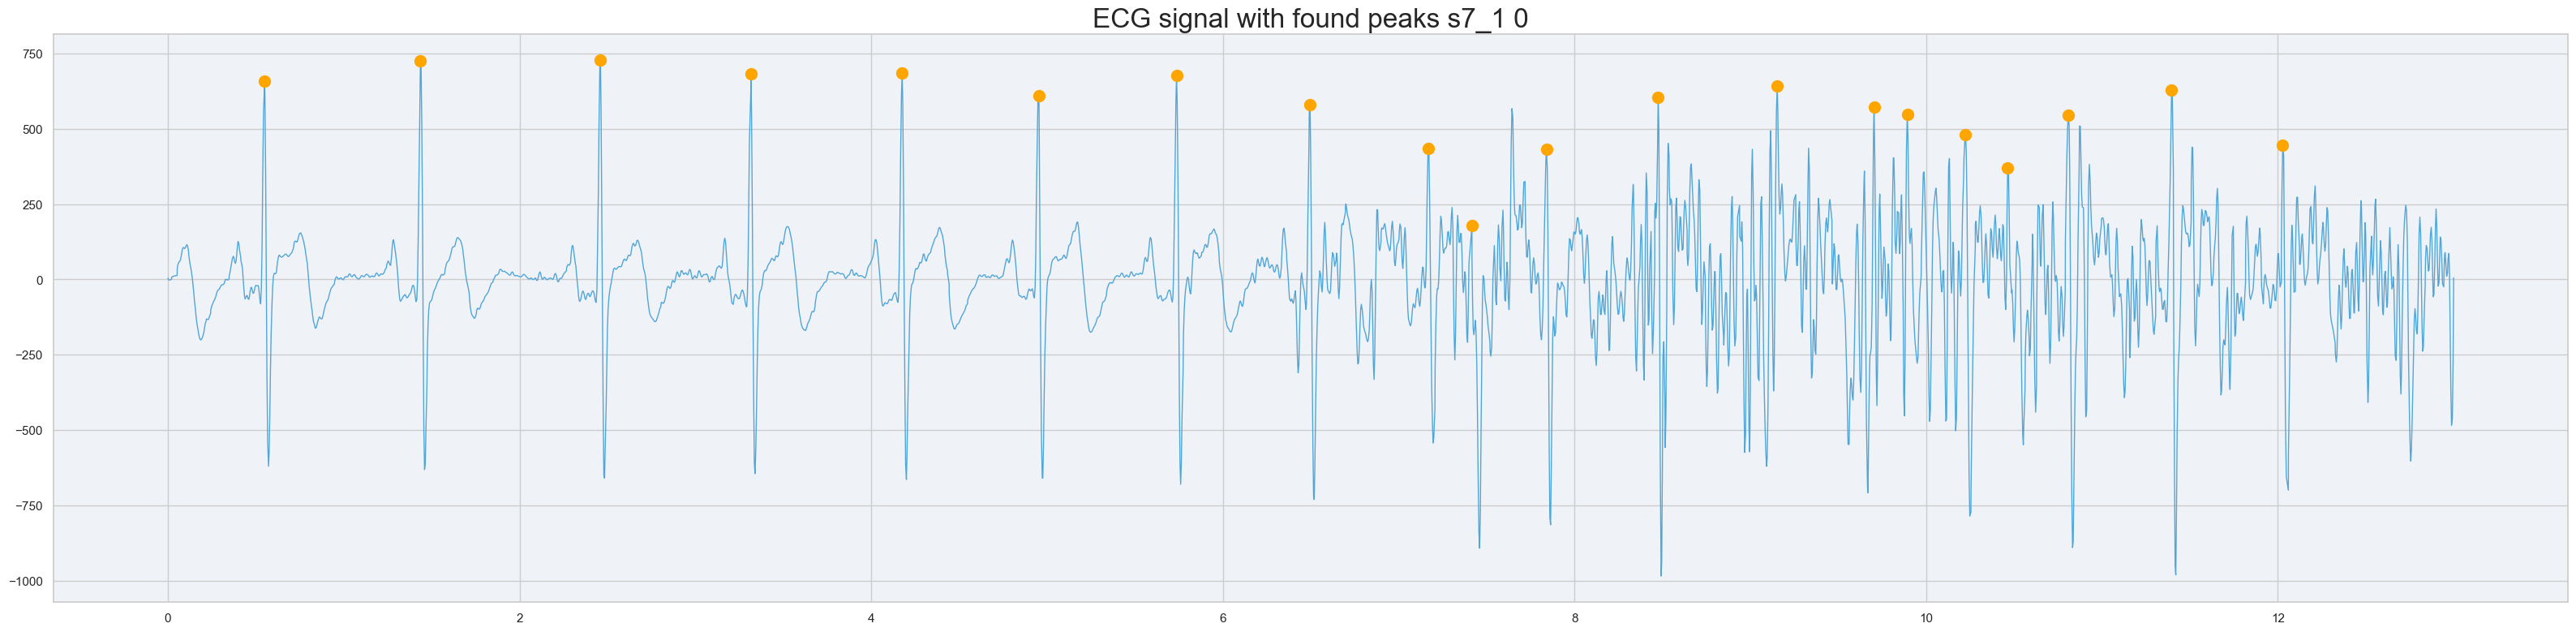

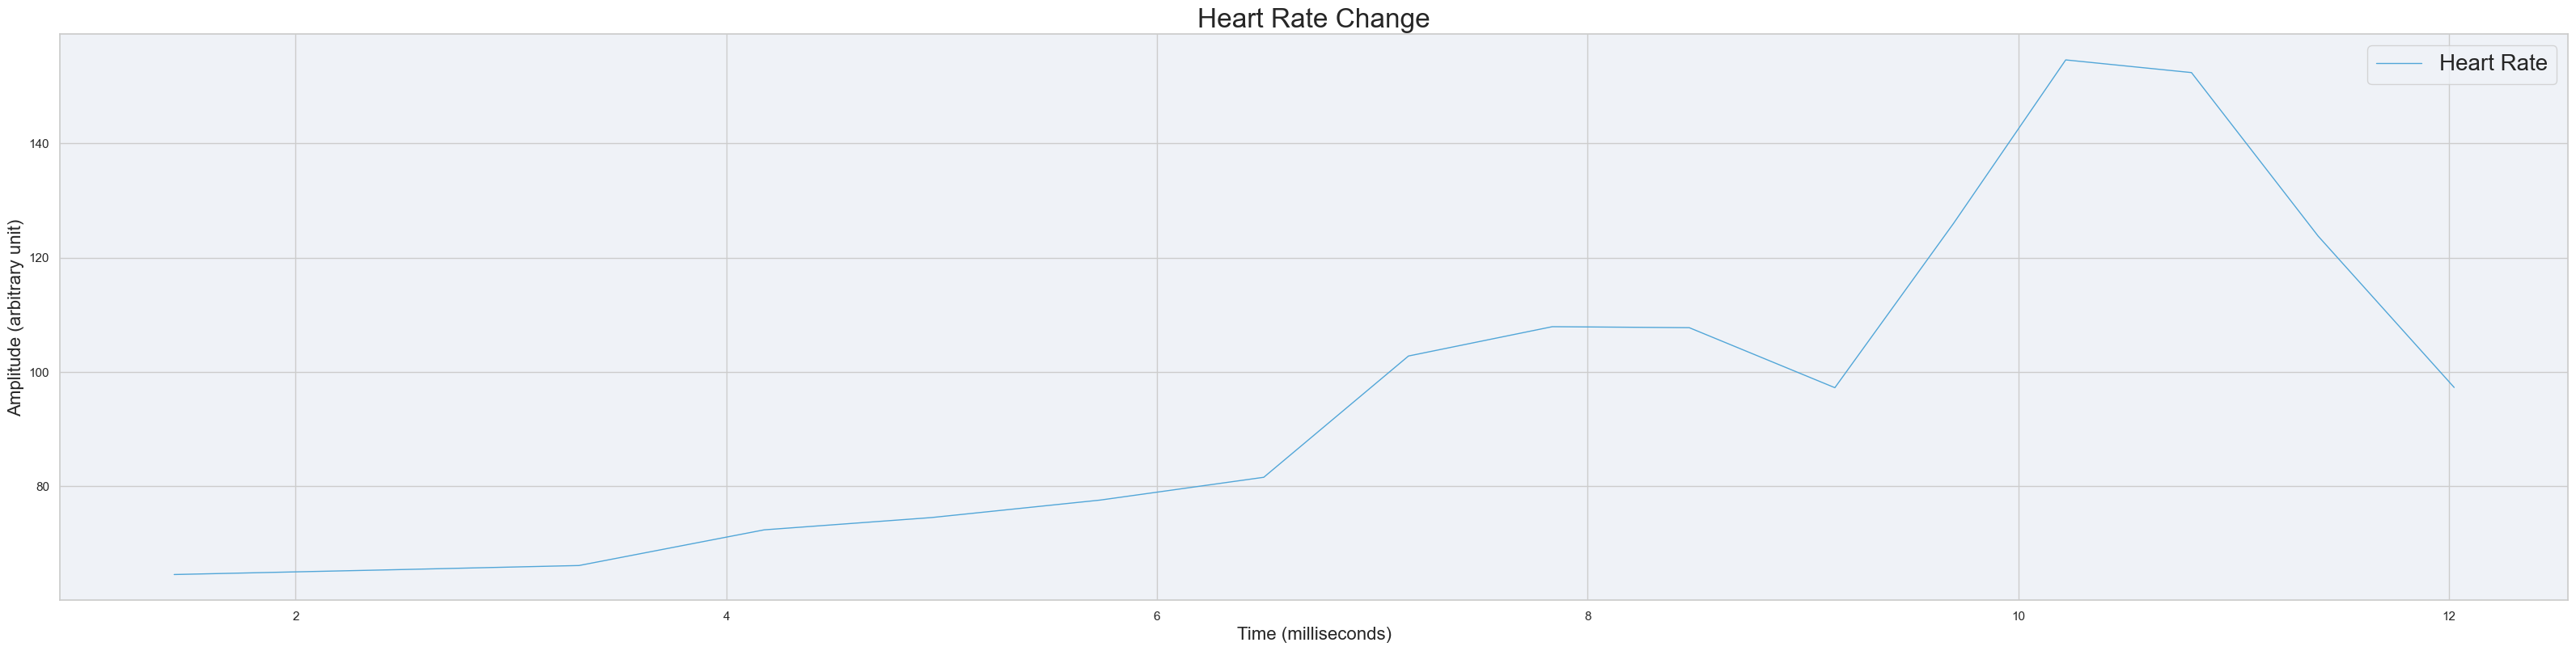

======Next Sampling Window======
start_stop:  (9998, 13248)
times[start], times[stop]:  -0.0009685409999917738 12.998855249999991
(start / 250) - takes_start_time_s[jf_id][0]:  -0.008000000000002672
Time domain: the rri sequence was detrended.
Signal duration must be greater than 20 seconds to compute frequency-domain features.
Signal duration must be greater than 90 seconds to compute non-linear features.
12.998855249999991 -13.005031624999987


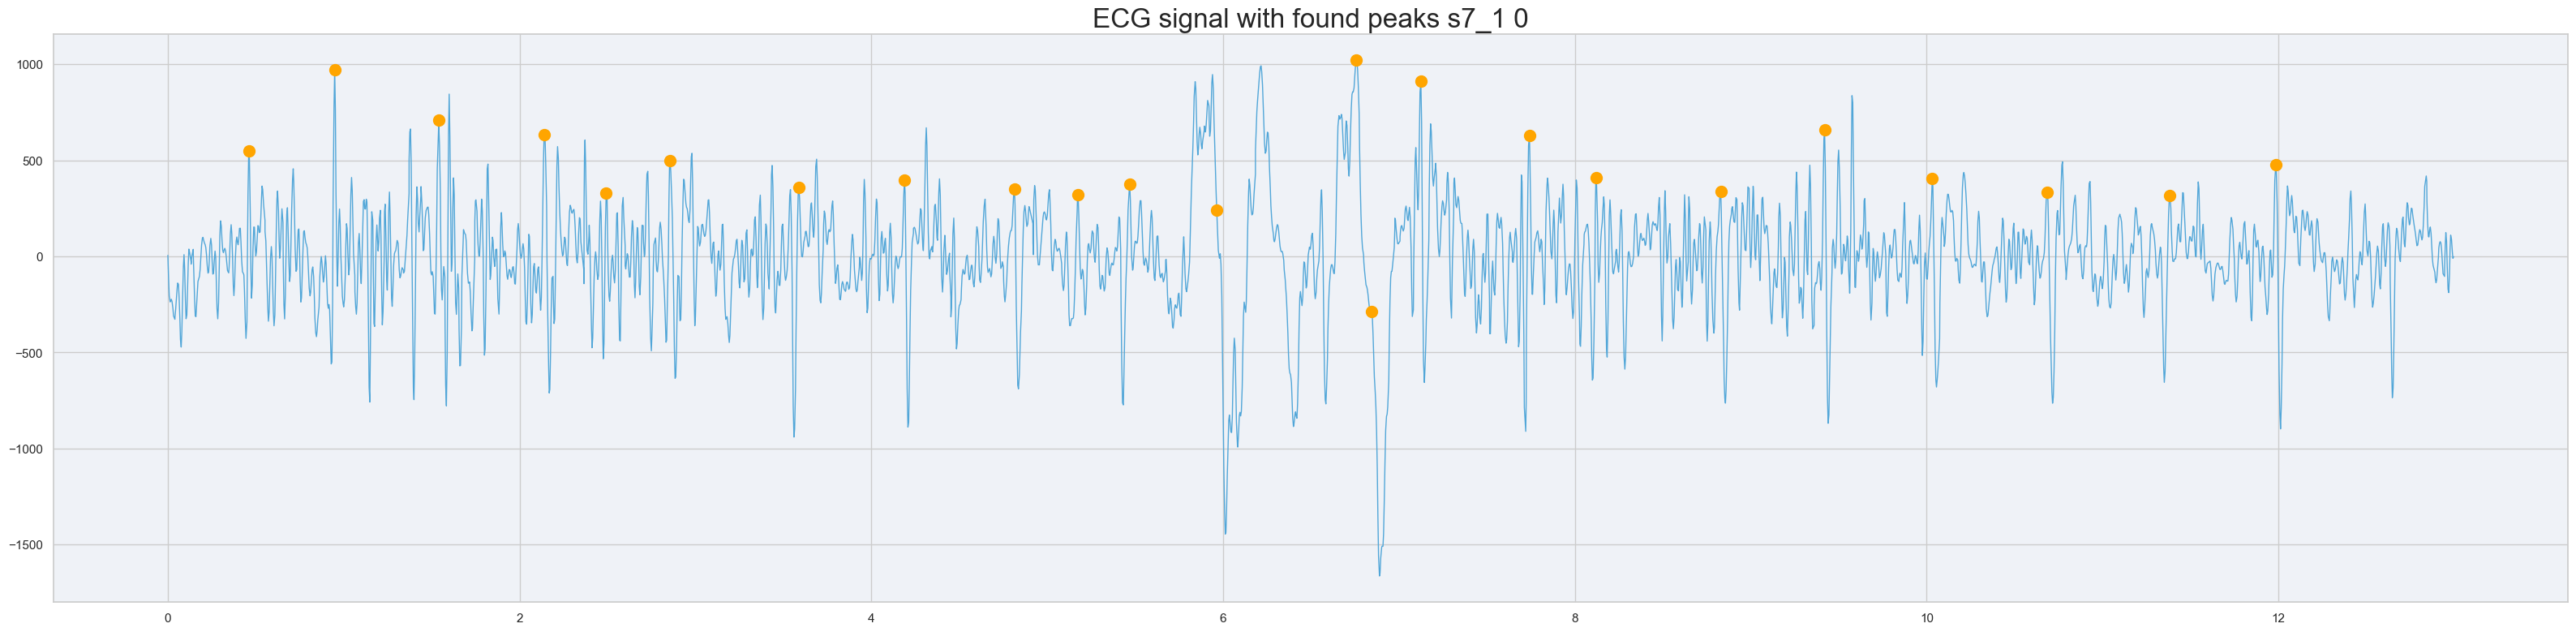

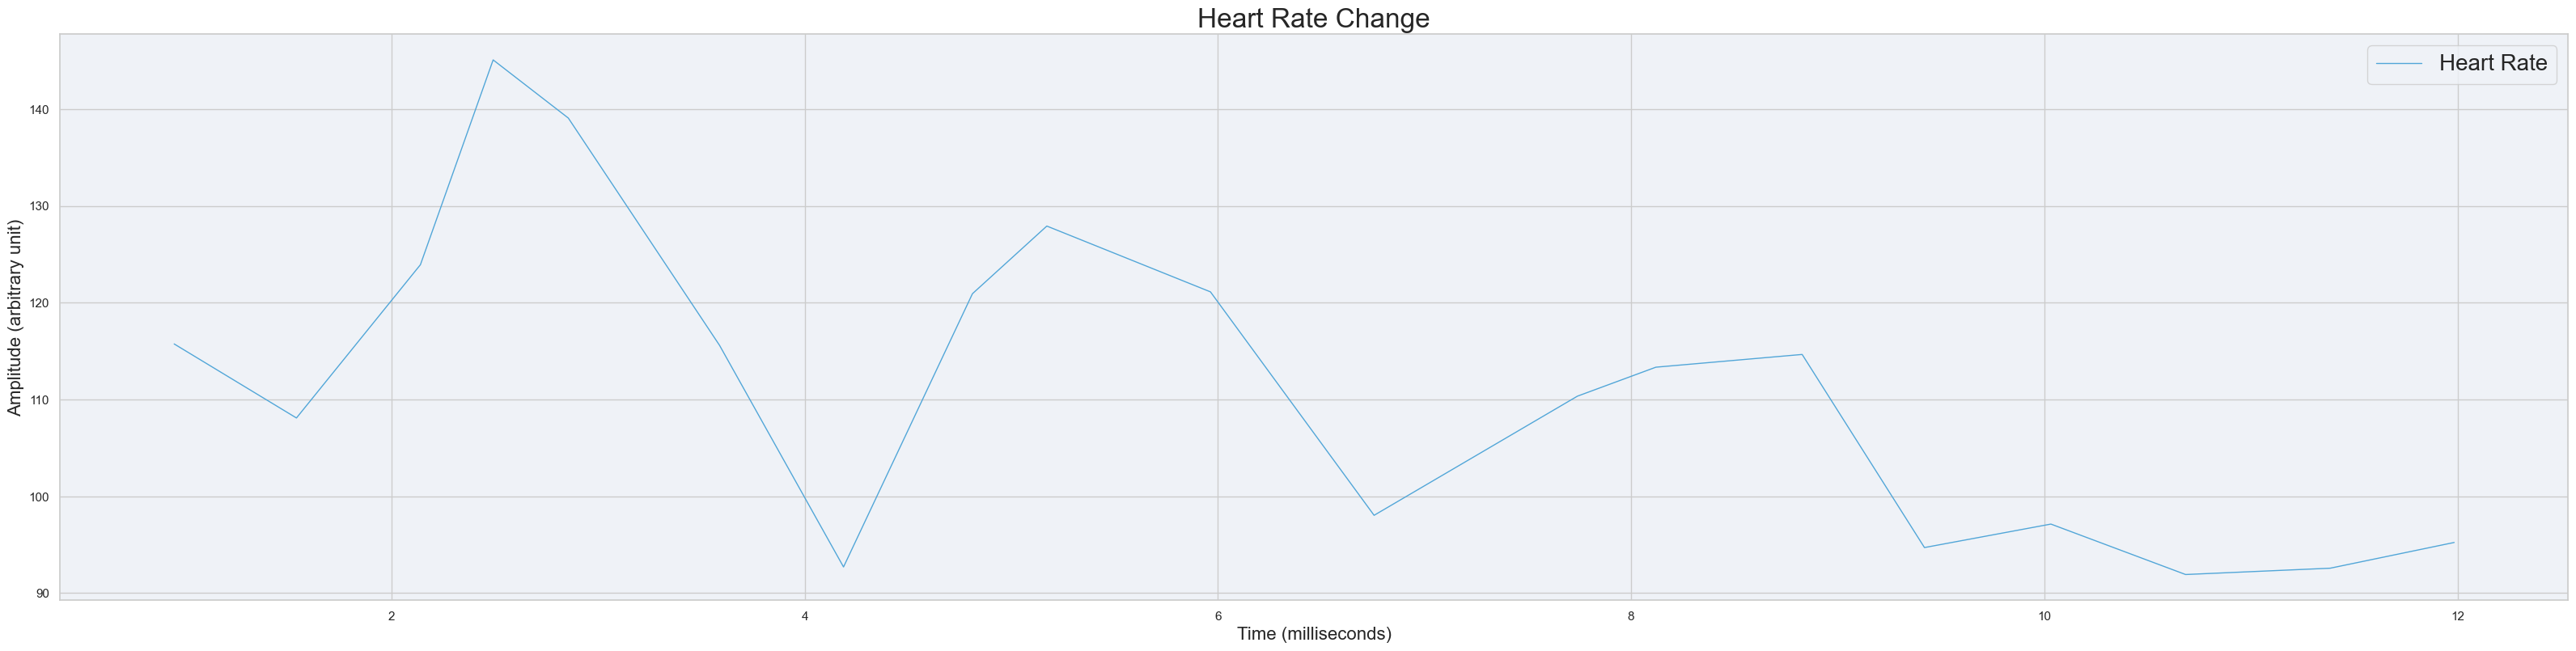

======Next Sampling Window======
start_stop:  (13248, 16498)
times[start], times[stop]:  12.998855249999991 26.002864417000012
(start / 250) - takes_start_time_s[jf_id][0]:  12.991999999999997
An error occurred: min() arg is an empty sequence
26.002864417000012 -13.005031624999987


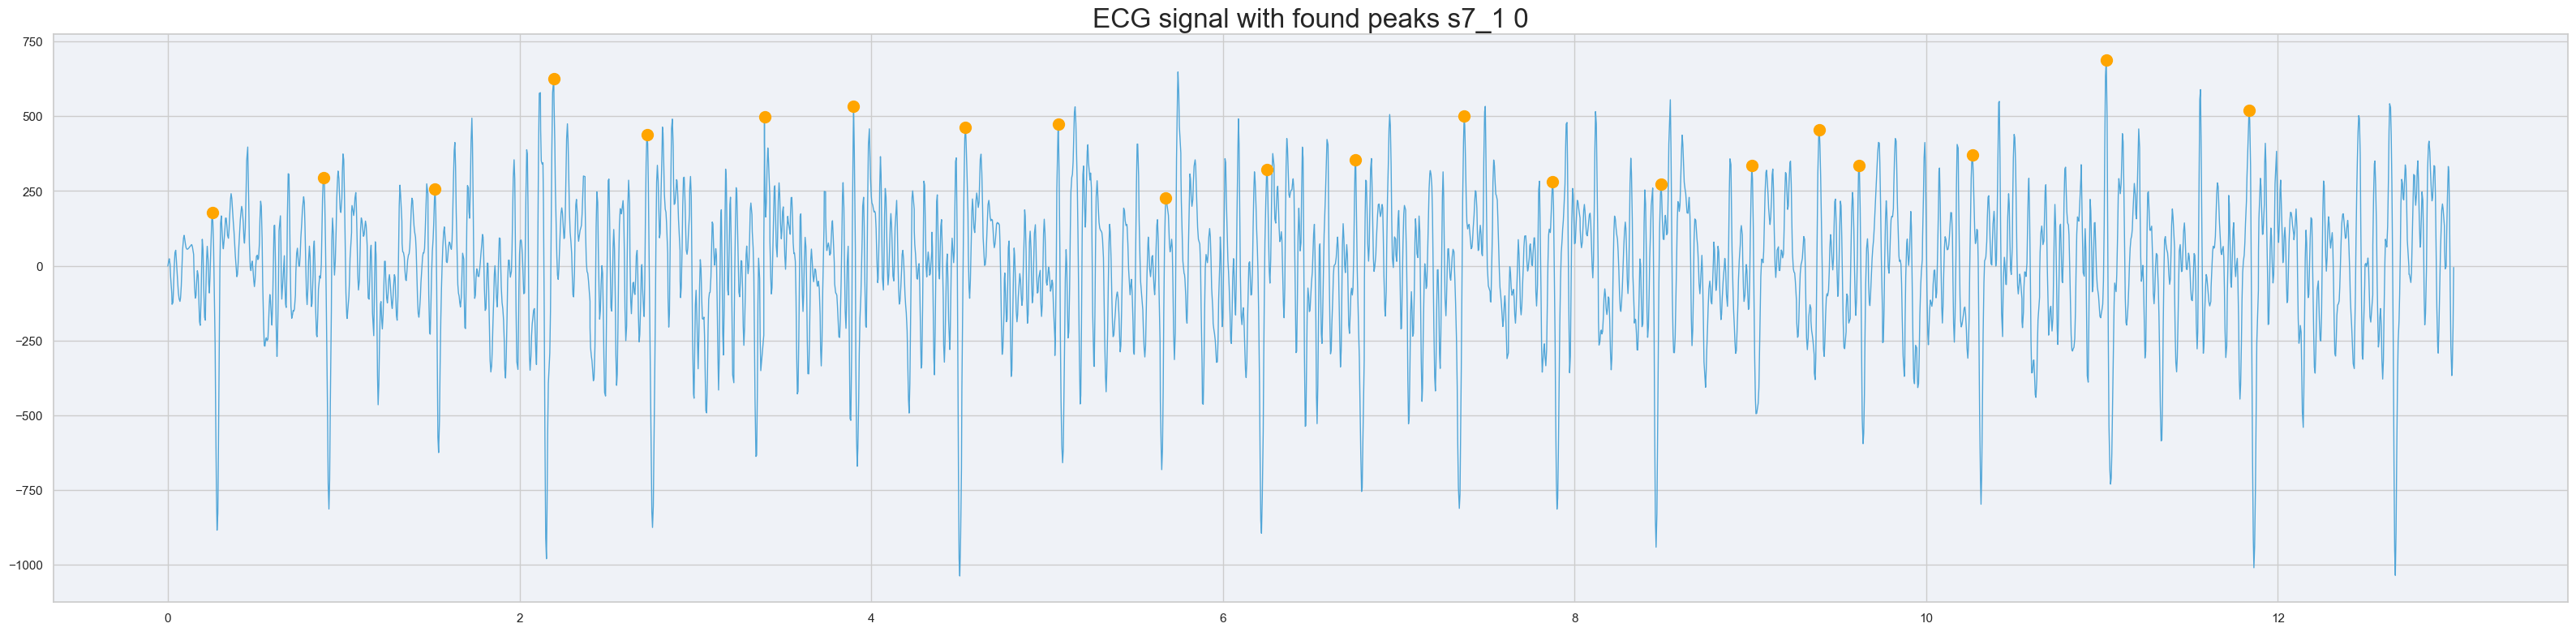

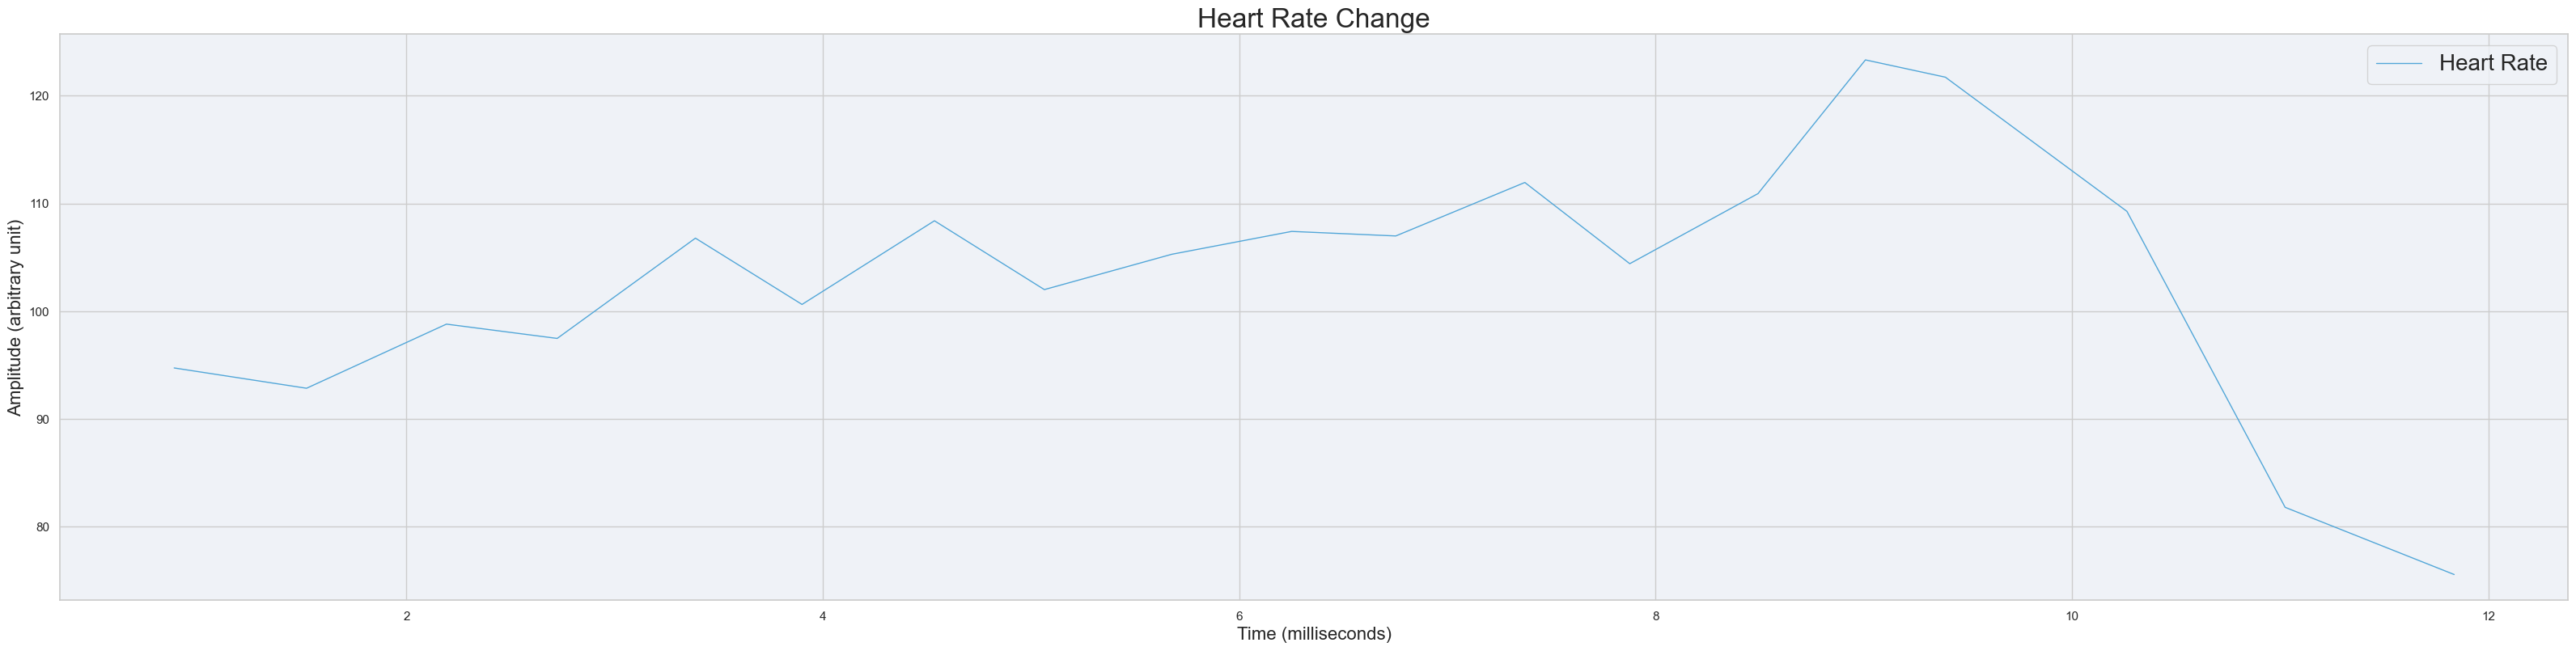

======Next Sampling Window======
start_stop:  (16498, 19748)
times[start], times[stop]:  26.002864417000012 39.0075645
(start / 250) - takes_start_time_s[jf_id][0]:  25.992000000000004
Time domain: the rri sequence was detrended.
Signal duration must be greater than 20 seconds to compute frequency-domain features.
Signal duration must be greater than 90 seconds to compute non-linear features.
39.0075645 -13.005031624999987


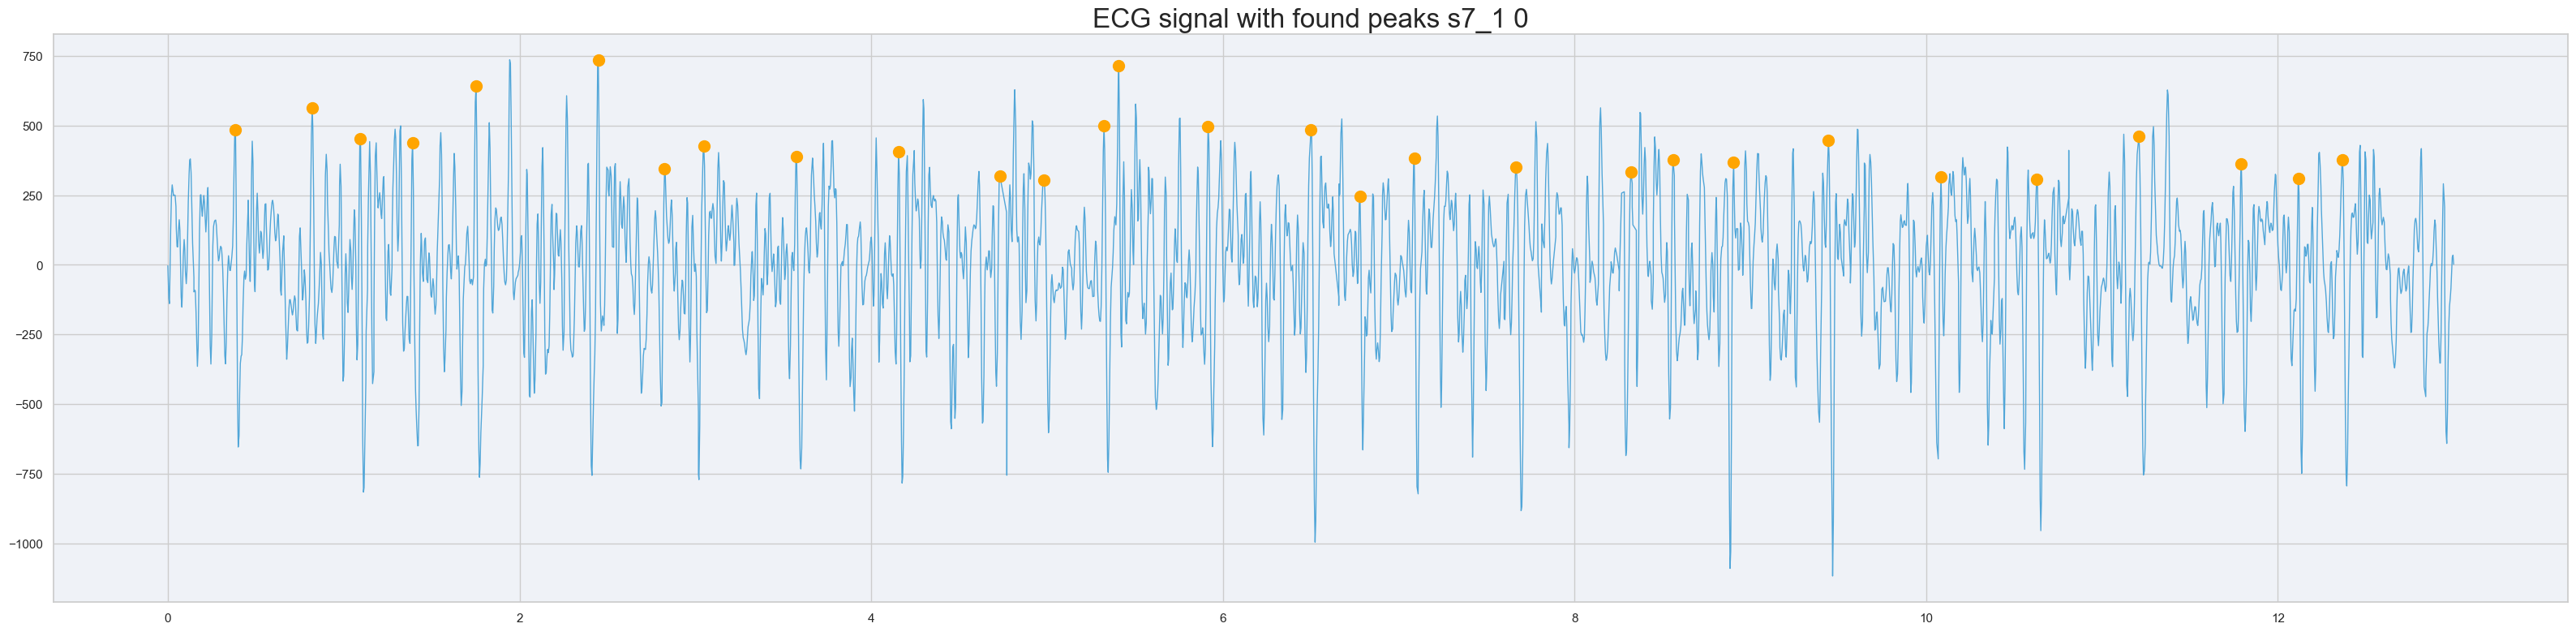

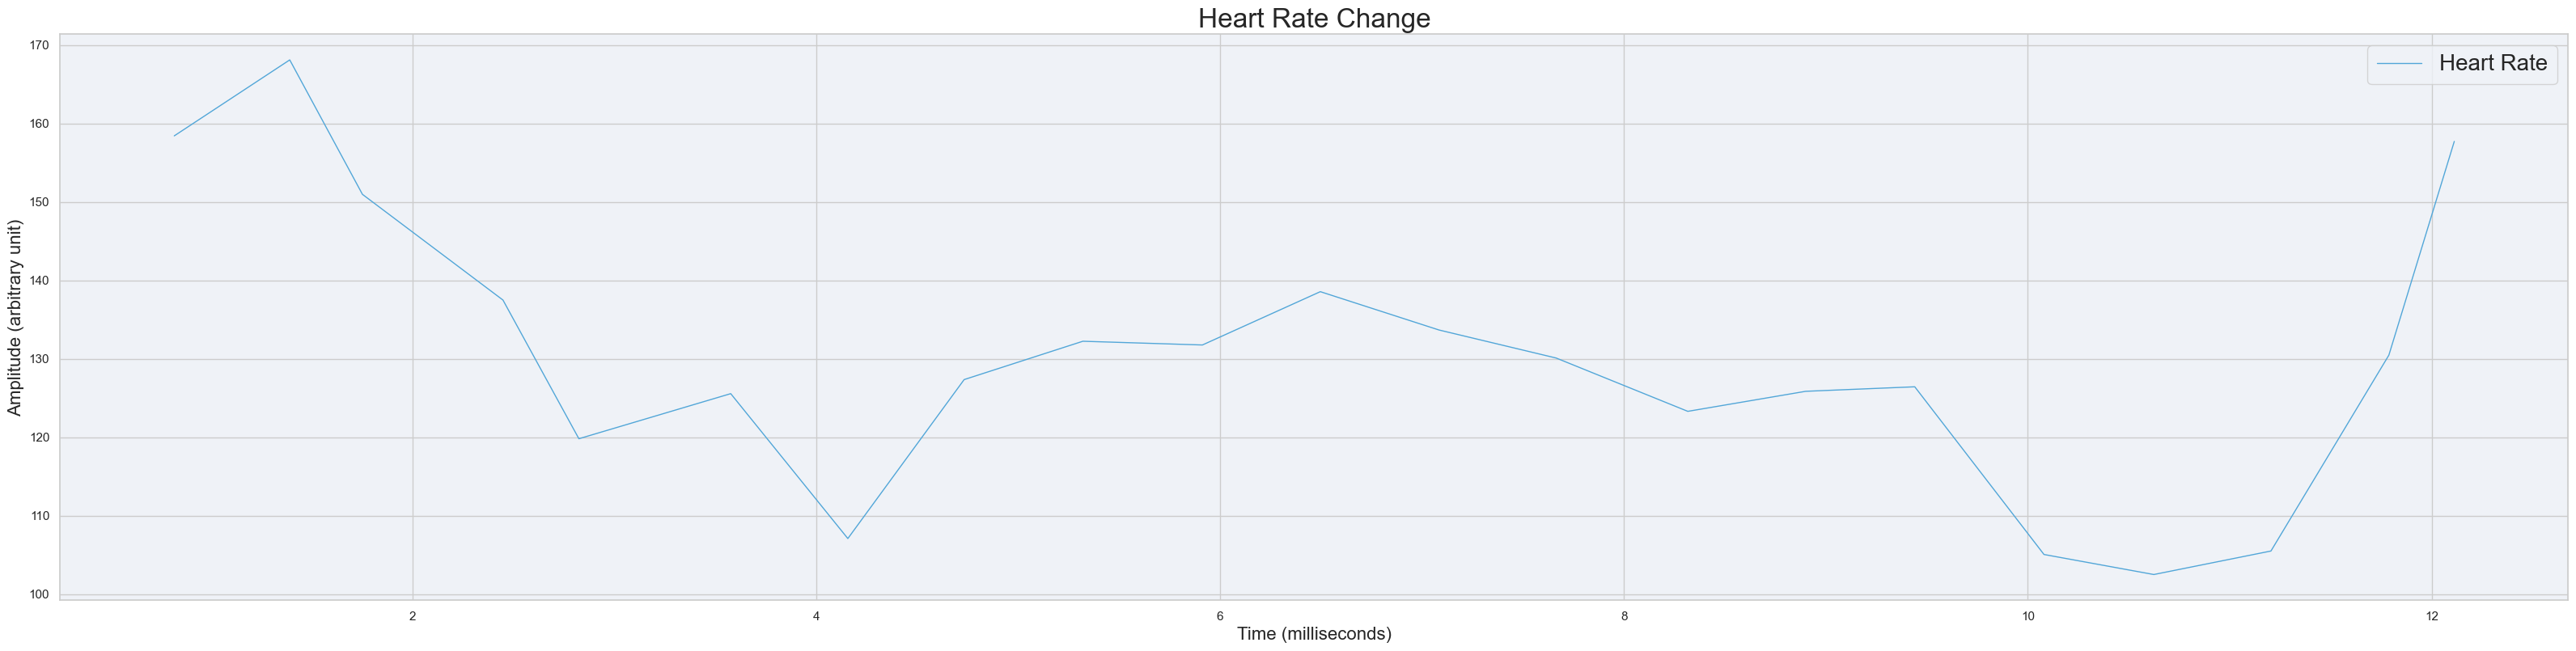

======Next Sampling Window======
start_stop:  (19748, 22998)
times[start], times[stop]:  39.0075645 52.007589584000016
(start / 250) - takes_start_time_s[jf_id][0]:  38.992000000000004
Time domain: the rri sequence was detrended.
Signal duration must be greater than 20 seconds to compute frequency-domain features.
Signal duration must be greater than 90 seconds to compute non-linear features.
52.007589584000016 -13.005031624999987


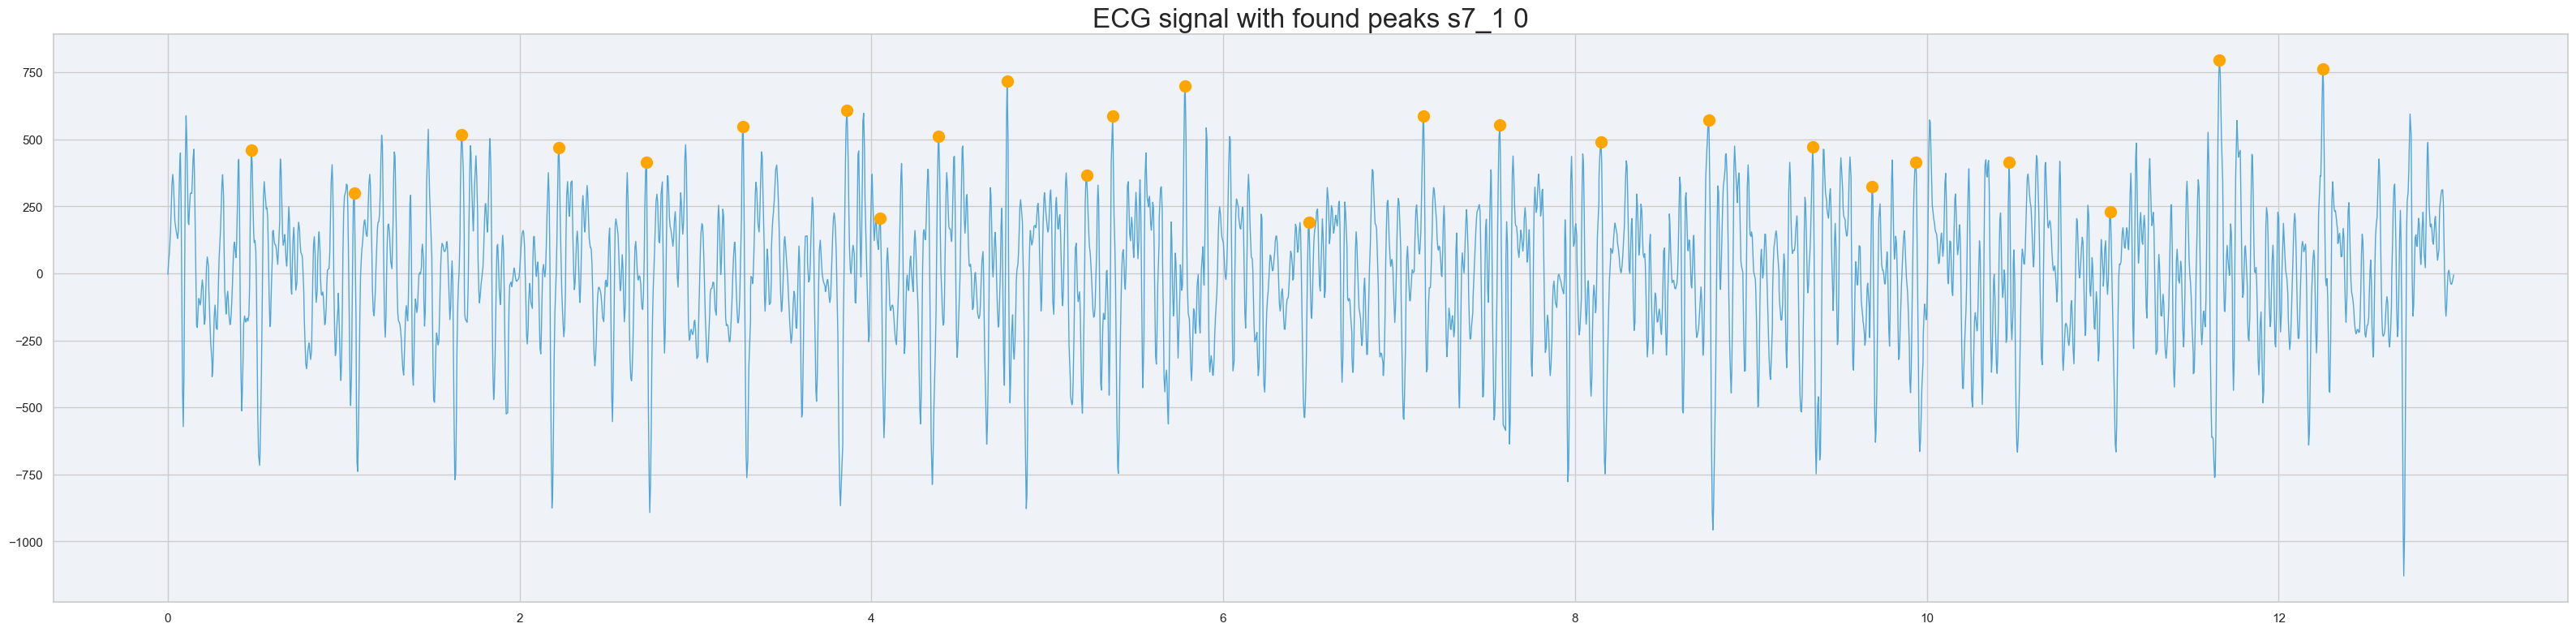

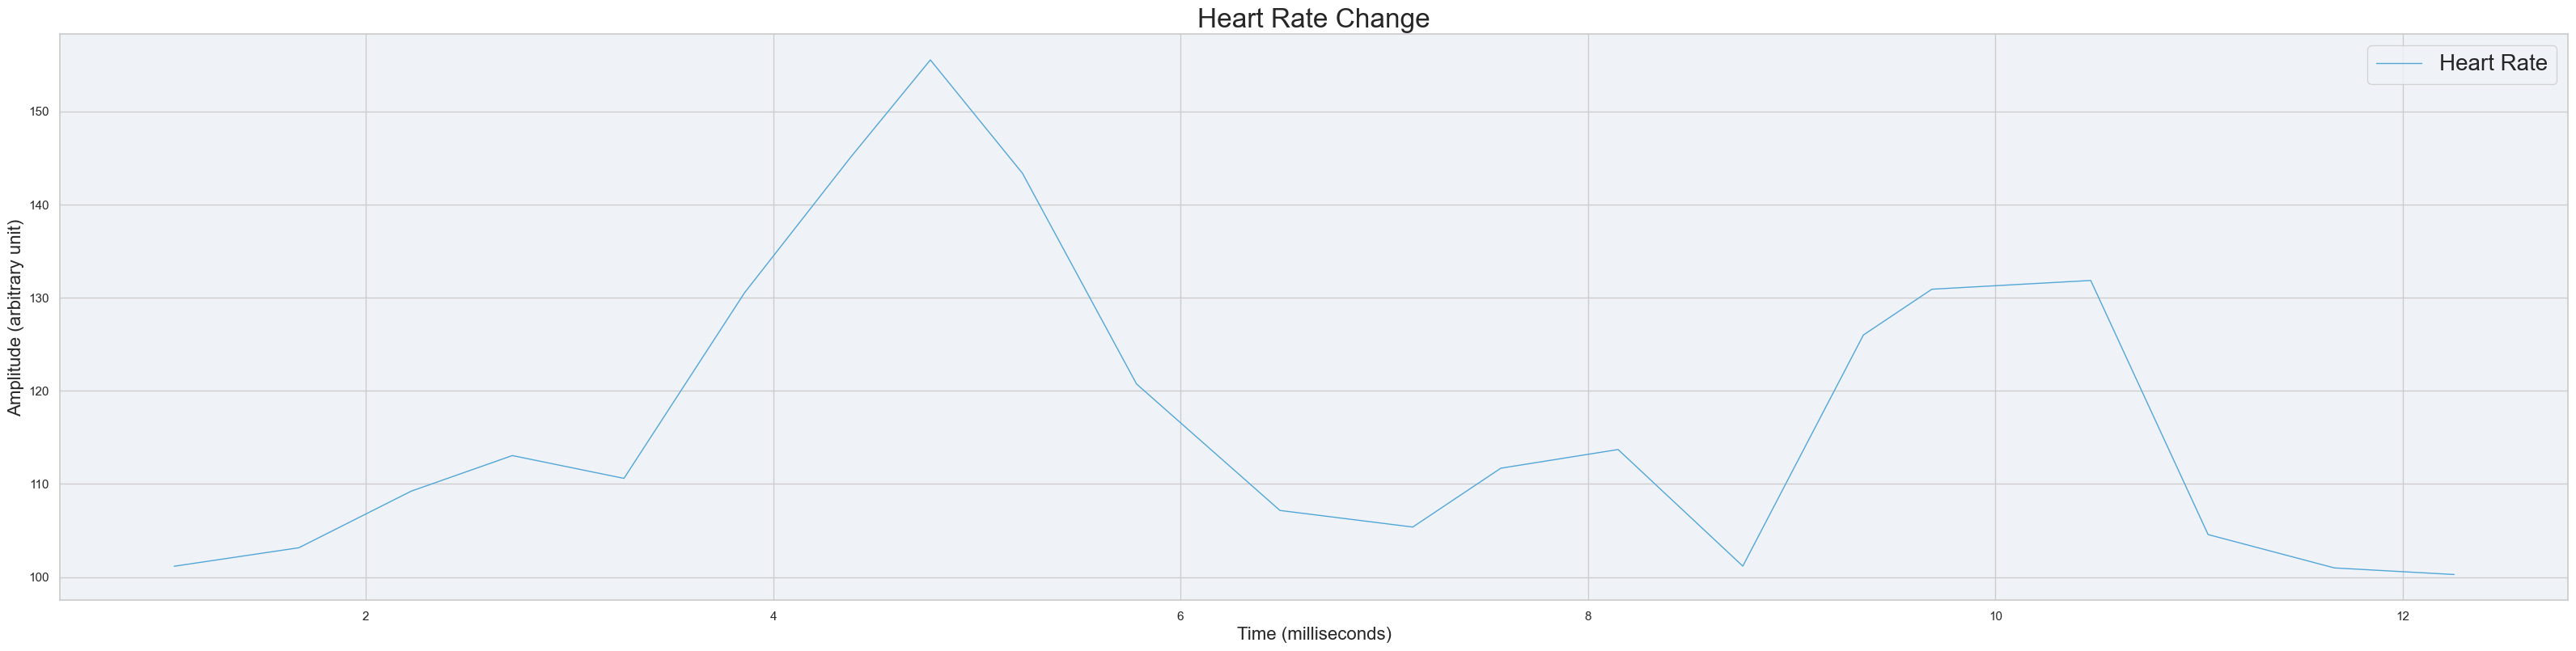

======Next Sampling Window======
start_stop:  (22998, 26248)
times[start], times[stop]:  52.007589584000016 65.00796595900002
(start / 250) - takes_start_time_s[jf_id][0]:  51.992000000000004
Time domain: the rri sequence was detrended.
Signal duration must be greater than 20 seconds to compute frequency-domain features.
Signal duration must be greater than 90 seconds to compute non-linear features.
65.00796595900002 -13.005031624999987


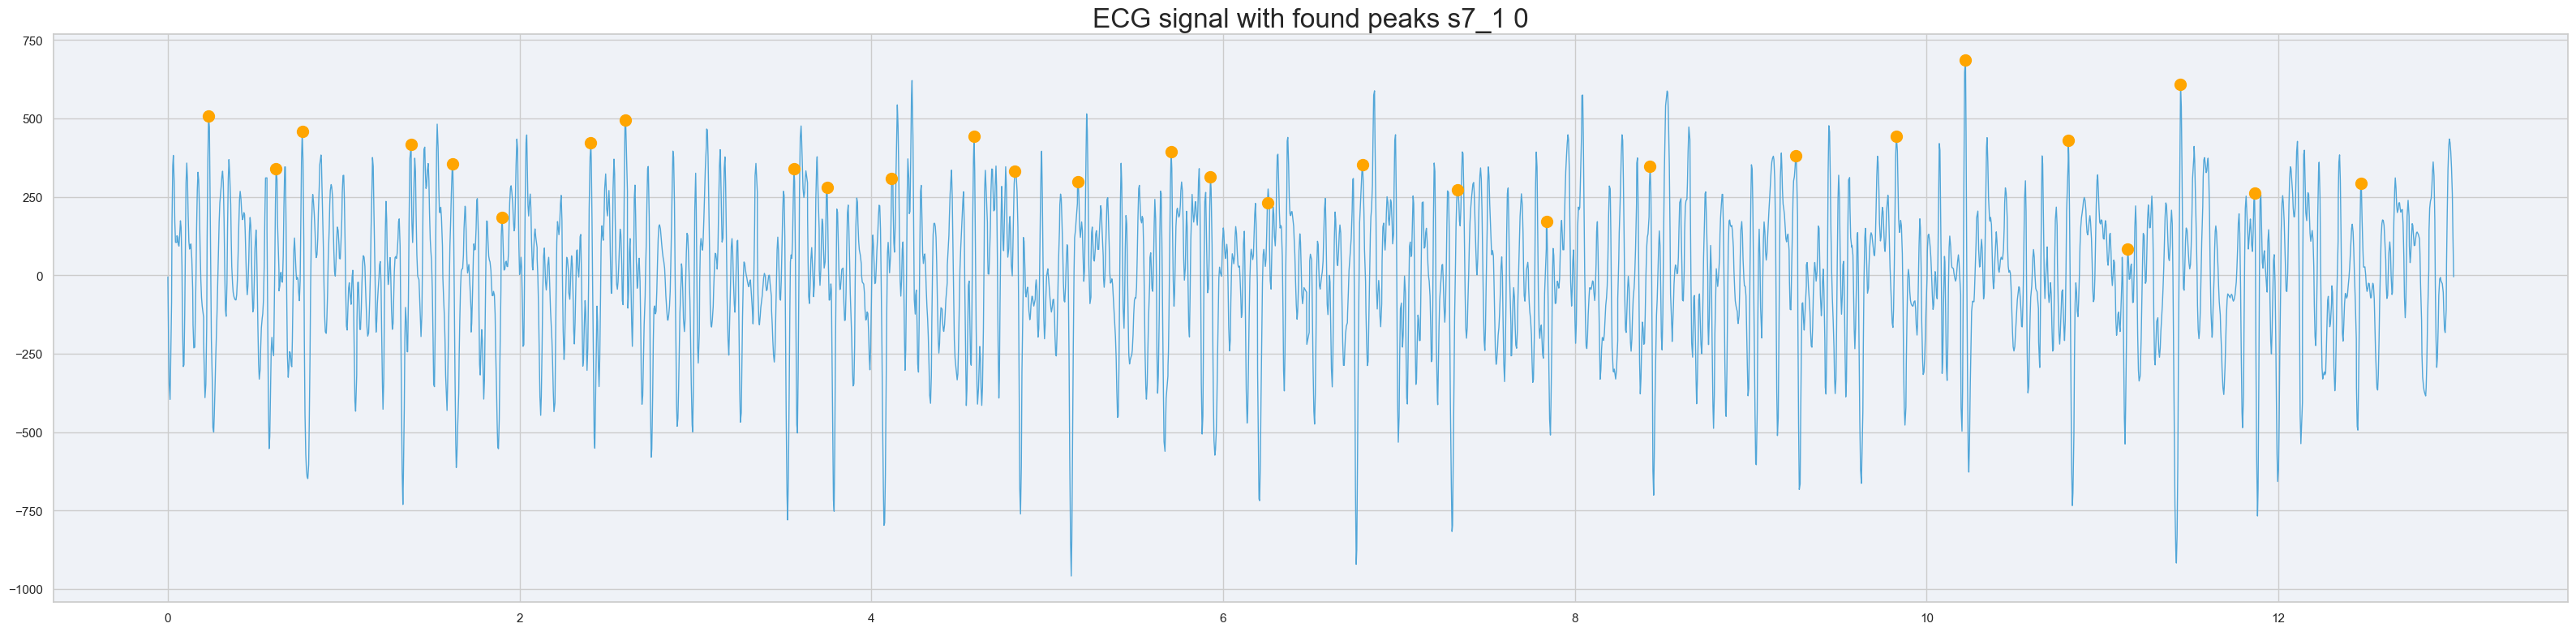

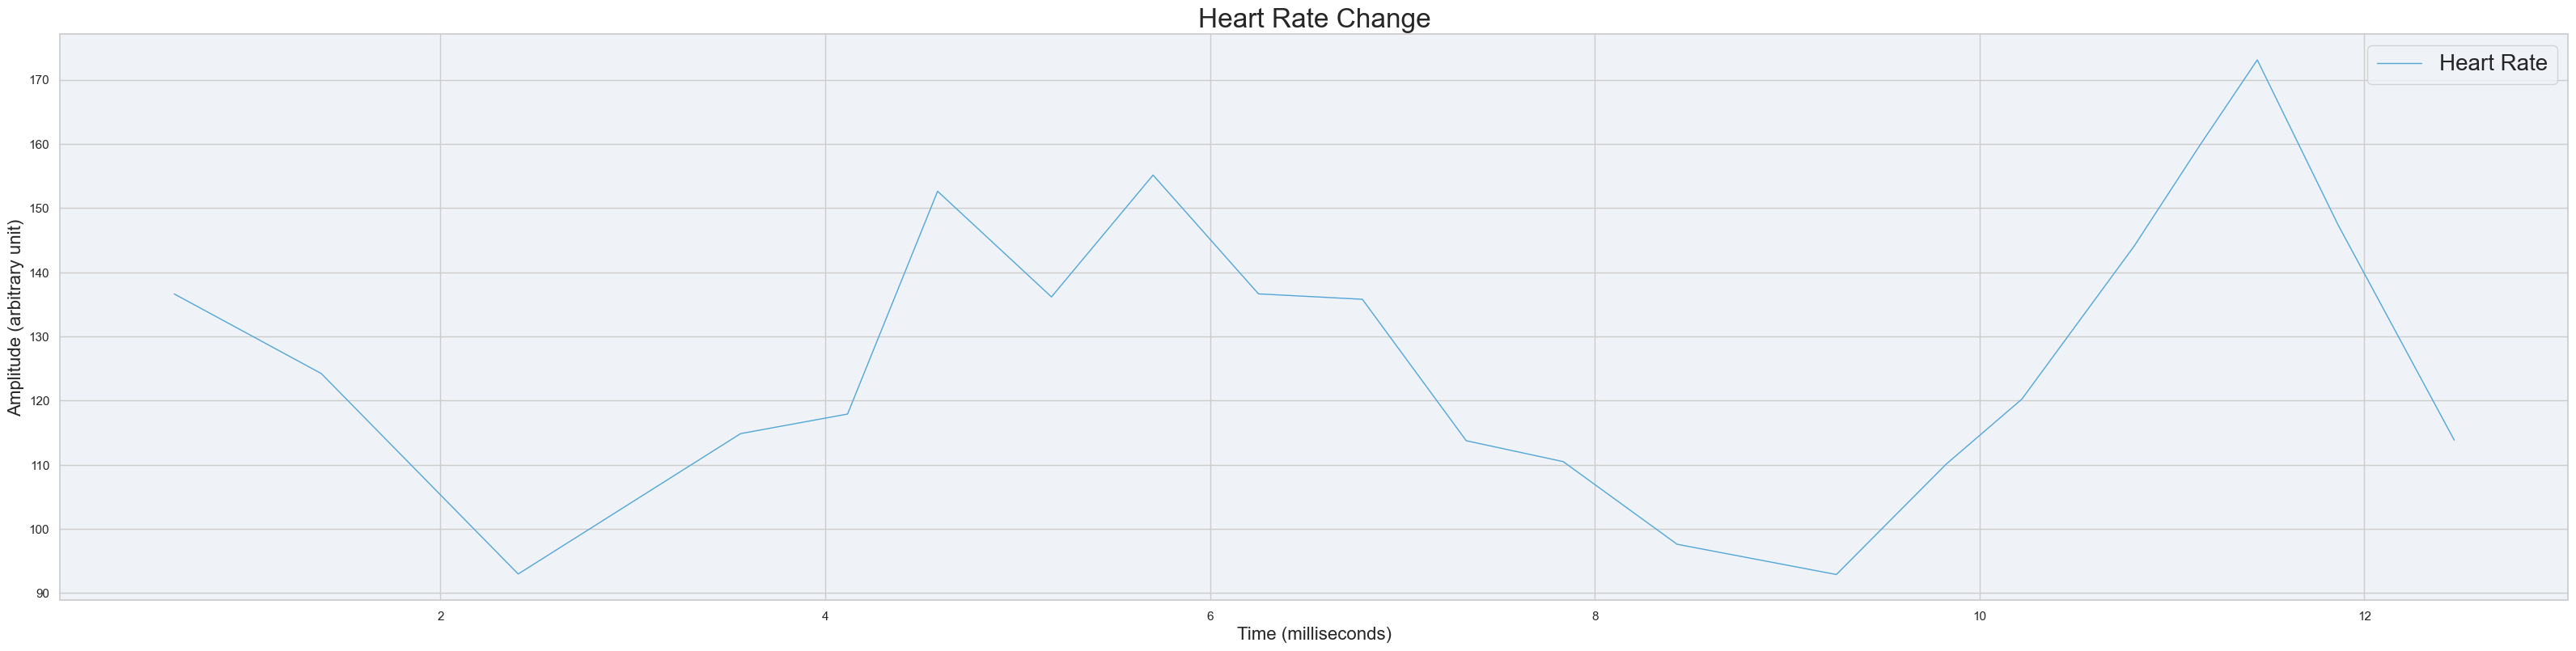

======Next Sampling Window======
start_stop:  (26248, 29498)
times[start], times[stop]:  65.00796595900002 78.007472167
(start / 250) - takes_start_time_s[jf_id][0]:  64.992
78 - times[stop]:  -0.007472167000003083
Time domain: the rri sequence was detrended.
Signal duration must be greater than 20 seconds to compute frequency-domain features.
Signal duration must be greater than 90 seconds to compute non-linear features.
78.007472167 -13.005031624999987


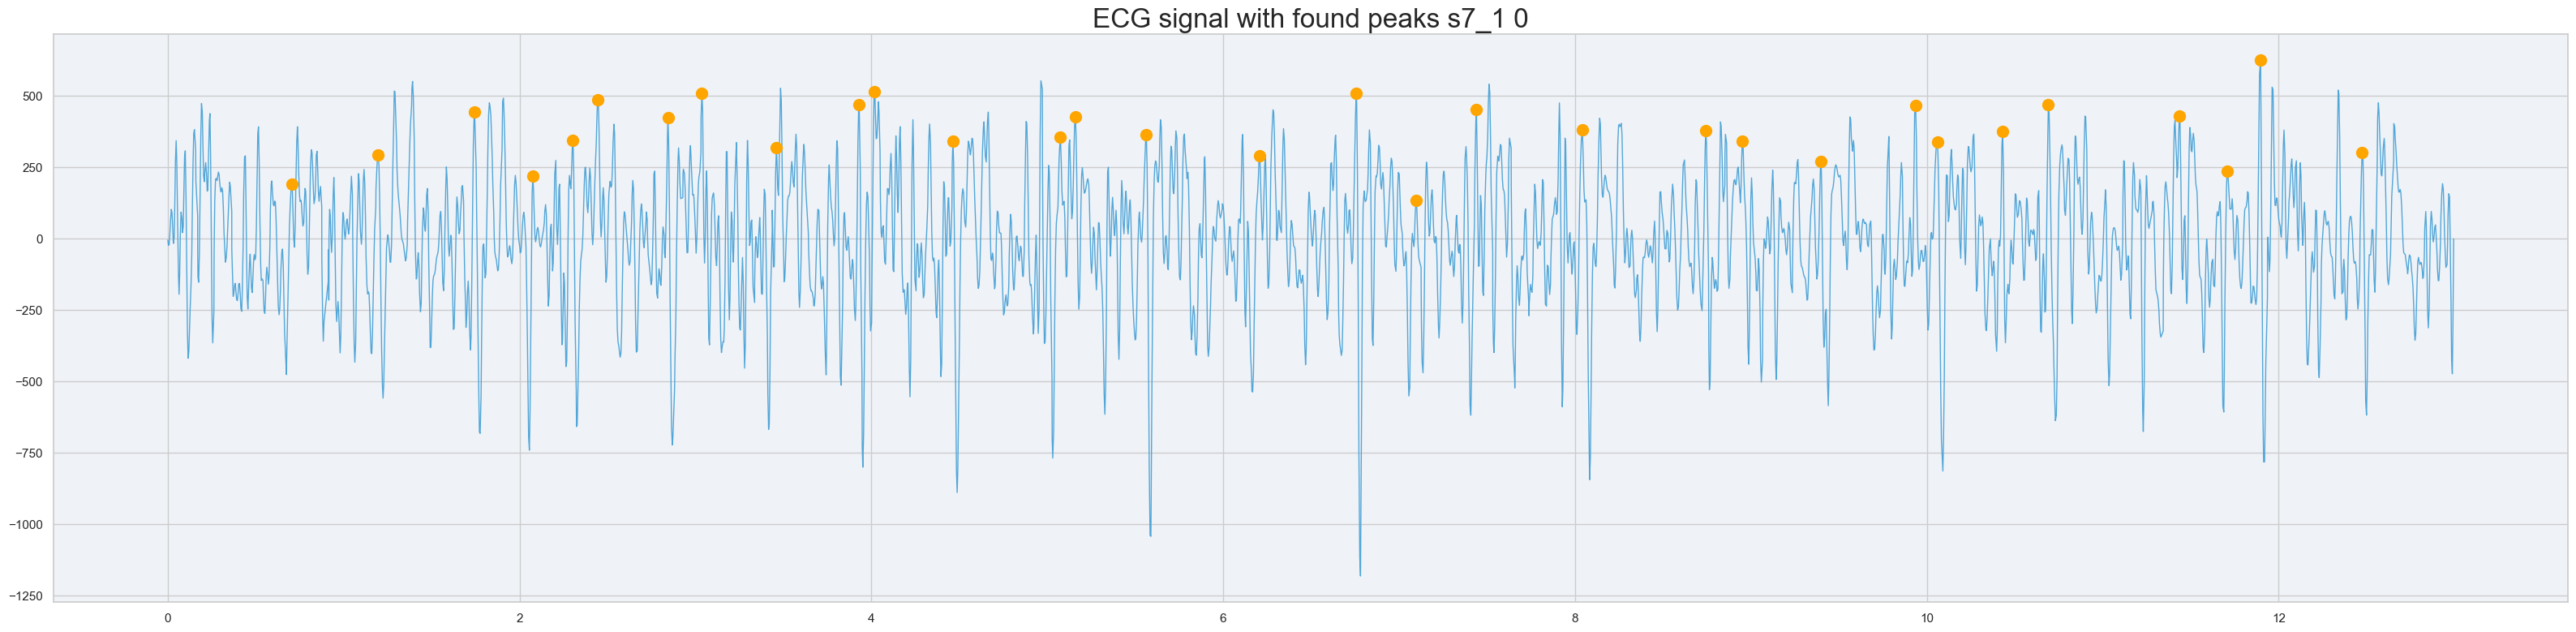

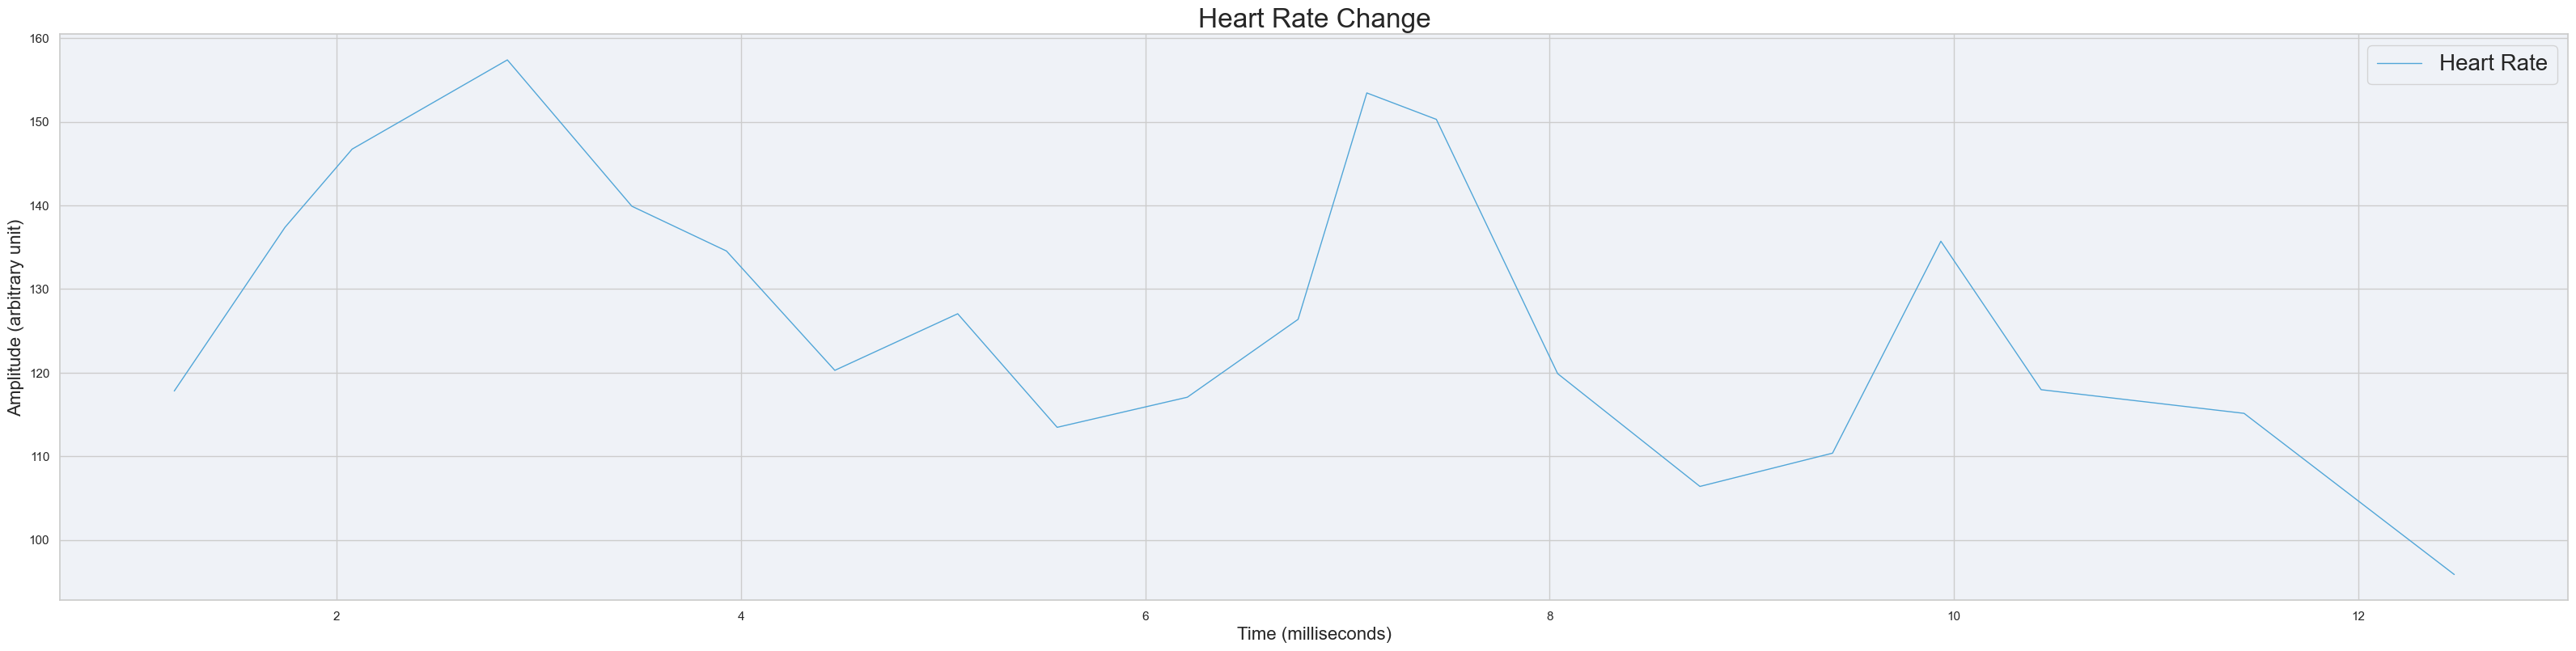

In [44]:
show_raw = True
nr_plots = 1

feature_sample_id = 0

# 13 seconds
window_size = int(13000 / 4)

# Files
for jf_id, jf in enumerate(filtered_json_files_list[:1]):
    times, sensors, duration = get_data_from_json(jf_id, dev_id, channel, False)
    # takes_start_time = np.array(takes_start_time_s[jf_id]) - int(14000/4)
    start_time_index = [np.where(
        # times==min(times, key=lambda x:abs(x-start_time)))[0][0] for start_time in takes_start_time_s[jf_id]]
        times==min(times, key=lambda x:abs(x-start_time)))[0][0] for start_time in takes_start_time_s[jf_id]]
        # end_time_seconds = np.add(start_times, durations).tolist()
    end_time_index = [np.where(
        times==min(times, key=lambda x:abs(x-end_time)))[0][0] for end_time in film_durations[jf_id]]
    last_end_index = 0
    for ranges in get_masked_ranges(start_time_index, end_time_index, len(times)):
        # print(ranges, last_end_index)
        # sensors = zero_until_range(sensors, ranges[0] if ranges[1] != len(times) else len(times), last_end_index)
        last_end_index = ranges[1]
    times = times[:] - takes_start_time_s[jf_id][0]

    # times, sensors, duration = get_data_from_json(jf_id, dev_id, channel, False)
    df = pd.DataFrame({"index": times, "heartrate": sensors})
    df_slice = [pd.DataFrame() for _ in range(len(film_durations[jf_id]))]

    plot_ranges = []
    # Takes
    for take, ranges in enumerate(get_masked_ranges(start_time_index, end_time_index, len(times))[:-1]):
        print("======Next Take======")
        sampfrom, sampto = ranges

        if current_label == "ECG":
            sampfrom = sampfrom - window_size # - 13s
            sampto = sampfrom + (window_size * 7)
            print("ranges", sampfrom, sampto)
            plot_ranges = split_window(sampfrom, sampto, min_size=window_size)

        if current_label == "EDA" or current_label == "ACC":
            window_size = sampto - sampfrom
            plot_ranges = get_plot_ranges(sampfrom, sampto, nr_plots)

        hrv_graph = [[]]
        eda_graph = [[]]

        print("session, ", identifiers[jf_id])
        print("take: ", take)
        print("processing features for ", current_label)
        # Sampling Windows
        for i, start_stop in enumerate(plot_ranges):
        # for i, start_stop in enumerate(get_plot_ranges(sampfrom, sampto, nr_plots)):
            print("======Next Sampling Window======")
            start, stop = start_stop

            # if (current_label == "ECG"):
            #     start = start - window_size

            print("start_stop: ", start_stop)
            print("times[start], times[stop]: ", times[start], times[stop])
            print("(start / 250) - takes_start_time_s[jf_id][0]: ", (start / 250) - takes_start_time_s[jf_id][0])
            if (78 - times[stop] < 12):
                print("78 - times[stop]: ", 78 - times[stop])

            # get slice data of sensor data
            cond_slice = (df.index >= start) & (df.index < stop)
            if (current_label != "ACC"):
                ecg_slice = df.heartrate[cond_slice]
                x_slice = ecg_slice
            else:
                x_slice = df.heartrate[cond_slice]
                ecg_slice = [[acc[0],acc[1],acc[2]] for acc in df.heartrate[cond_slice]]

            df_slice[take] = pd.DataFrame({"index": x_slice, "sensors": ecg_slice})

            if (len(ecg_slice) > 1125):
                if (current_label == "ECG"):
                    ecg_stats = ecg.ecg(signal=ecg_slice, sampling_rate=1000/4, show=0)
                    t, ecg_slice_filtered, peaks = ecg.ecg(signal=ecg_slice, sampling_rate=1000/4, show=0)[:3]
                    try:
                        hrv_features = hrv.hrv(rpeaks=peaks, sampling_rate=1000/4, outliers="interpolate", show=1, show_individual=False)
                        # print(hrv_features[])
                    except Exception as e:
                        print(f"An error occurred: {e}")
                        pass
                    try:
                        if (hrv_features[10]):
                            print(times[stop], times[sampfrom])
                            hrv_graph.append([times[stop - window_size] - times[sampfrom], hrv_features[10]])
                            # print(hrv_graph)
                        else:
                            continue
                    except Exception as e:
                        print(f"An error occurred: {e}")
                        pass
                    # rri = hrv.rri_correction(rri=hrv_features)
                    # hrv_time_features = hrv.hrv_timedomain(rri=hrv_features, duration=times[stop]-times[start], show=True)
                    # results = td.rmssd(nni=rri)
                if (current_label == "ACC"):
                    ecg_stats = acc.acc(signal=ecg_slice, sampling_rate=1000/10, interactive=0, show=0)
                    # ecg_slice_filtered = ecg_stats[1]
                    df_slice[take]["magnitude"] = ecg_stats[2]
                    df_slice[take]["smoothed"] = df_slice[take]["magnitude"].ewm(alpha=0.25, adjust=False).mean()
                    ecg_slice_filtered = df_slice[take]["smoothed"]

                    n_parts = 2
                    split_signals = np.array_split(ecg_stats[1], n_parts)
                    for i, window in enumerate(split_signals):
                        spectrum_features = acc.frequency_domain_feature_extractor(signal=window, sampling_rate=1000/10)
                        plt.figure(figsize=(3, 3))
                        for axs in ["x", "y", "z"]:
                            plt.plot(spectrum_features[0][axs], spectrum_features[1][axs])
                        plt.xlim(0.0, 1.0)
                        plt.show()
                if (current_label == "EDA"):
                    try:
                        ecg_stats = eda.eda(signal=ecg_slice, sampling_rate=1000/10, show=0)
                        ecg_slice_filtered = ecg_stats[1]
                        # Extracted features (SCR, SCL, etc.)
                        peaks = ecg_stats[5]
                        onsets = ecg_stats['onsets']
                        edl = ecg_stats['edl']  # Skin conductance level
                        edr = ecg_stats['edr']  # Skin conductance response
                        ecg_slice_filtered = ecg_stats['filtered']  # The filtered EDA signal

                        eda_graph = [times[onsets] + takes_start_time_s[jf_id][0], times[peaks] + takes_start_time_s[jf_id][0]]
                        # print(eda_graph)
                    except Exception as e:
                        eda_graph = [[], []]
                        print(f"An error occurred: {e}")
            else:
                break

            if (show_raw):
                plt.figure(figsize=(40, 20))
                plt.subplot(211)
                plt.title(f"{current_label} signal with found peaks {identifiers[jf_id]} {take}" if current_label != "ACC" else f"{current_label} signal", fontsize=24)

            if (current_label != "ACC" and show_raw):
                plt.plot(times[ecg_slice.index] - times[x_slice.index][0], ecg_slice_filtered, label=current_label, color="#51A6D8", linewidth=1)
                plt.plot(times[peaks+start] - times[x_slice.index][0], ecg_slice_filtered[peaks], markersize=10, label="R-peak", color="orange", marker="o", linestyle="None")
        #    triaxial data
            if (current_label == "ACC"):
                # plt.plot(times[x_slice.index], ecg_slice_filtered, label=current_label, color="#51A6D8", linewidth=3)
                # plt.plot(times[x_slice.index], (1*df_slice["second_order_diff"]) + 1, label=current_label, color="orange", linewidth=3)
                sns.lineplot(x=times[x_slice.index], y=ecg_slice_filtered,estimator=np.mean, errorbar='sd')
                plt.ylim(0.9, 1.1)
                # plt.annotate('This point is interesting!', xy=(0, 1), xytext=(0, 1), arrowprops=dict(facecolor='black', shrink=0.05))

            if (current_label == "ECG" and show_raw):
                plt.figure(figsize=(40, 20))
                plt.subplot(212)
                plt.title("Heart Rate Change", fontsize=24)
                plt.plot(ecg_stats[5], ecg_stats[6], label="Heart Rate", color="#51A6D8", linewidth=1)

            if (show_raw):
                plt.legend(loc="upper right", fontsize=20)
                plt.xlabel("Time (milliseconds)", fontsize=16)
                plt.ylabel("Amplitude (arbitrary unit)", fontsize=16)
                plt.show()


        # if (current_label == "ECG"):
        #     print("List is not empty" if len(hrv_graph[1])>0 else "List is empty")
        #     print(hrv_graph)
        #     if len(hrv_graph[1])>0:
        #         df_features[feature_sample_id] = pd.DataFrame(hrv_graph, columns=['x', 'y'])
        #     else:
        #         print("nothing here")
        #         result_df = pd.DataFrame({"x": np.linspace(0, 78, num=(78//13) + 1, dtype=int), "y": 0})
        #         df_features[feature_sample_id] = pd.DataFrame(result_df, columns=['x', 'y'])
        #     feature_sample_id += 1

#         if (current_label == "EDA"):
#             eda_window_split = int(13)
#             arr_np = np.array(eda_graph[1], dtype=float)
#             print(eda_graph[1])
#             print("List is not empty" if len(eda_graph[1])>0 else "List is empty")
#             if len(eda_graph[1])>0:
#                 peak_index_list = np.array(sorted(eda_graph[1]), dtype=int)
#                 bins = np.arange(0, peak_index_list.max() + 13, 13)
#                 bin_labels = bins[:-1]  # Use bin start values as labels
#                 counts, _ = np.histogram(peak_index_list, bins)
#                 result_df = pd.DataFrame({"x": bin_labels, "y": counts})
#                 df_features[feature_sample_id] = pd.DataFrame(result_df, columns=['x', 'y'])
#                 print(df_features[feature_sample_id])
#             else:
#                 print("no peaks here")
#                 result_df = pd.DataFrame({"x": np.linspace(0, 78, num=(78//13) + 1, dtype=int), "y": 0})
#                 df_features[feature_sample_id] = pd.DataFrame(result_df, columns=['x', 'y'])
#                 print(df_features[feature_sample_id])
#             feature_sample_id += 1
#
# if (current_label == "ECG"):
#     df_features[3]["y"].iloc[-1] = df_features[3]["y"].iloc[-1] - 54.0

0 s7_1
device data length:  (2, 783293)
start_time_seconds:  40.0
9998 16497 6499
0 0
783293 158727
DEBUG:  [0.054730959000011126]
0
s7_1
[287.0]
DEBUG 1
DEBUG 1
DEBUG s7_1
0.054730959000011126
DEBUG [286.94526904]
x_second_labels [  0   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34
  36  38  40  42  44  46  48  50  52  54  56  58  60  62  64  66  68  70
  72  74  76  78  80  82  84  86  88  90  92  94  96  98 100 102 104 106
 108 110 112 114 116 118 120 122 124 126 128 130 132 134 136 138 140 142
 144 146 148 150 152 154 156 158 160 162 164 166 168 170 172 174 176 178
 180 182 184 186 188 190 192 194 196 198 200 202 204 206 208 210 212 214
 216 218 220 222 224 226 228 230 232 234 236 238 240 242 244 246 248 250
 252 254 256 258 260 262 264 266 268 270 272 274 276 278 280 282 284 286
 288 290 292 294 296 298 300 302 304 306 308 310 312 314 316 318 320 322
 324 326 328 330 332 334 336 338 340 342 344 346 348 350 352 354 356 358
 360 362 364 366 368 370 372 374 376 37

<Figure size 4000x1000 with 0 Axes>

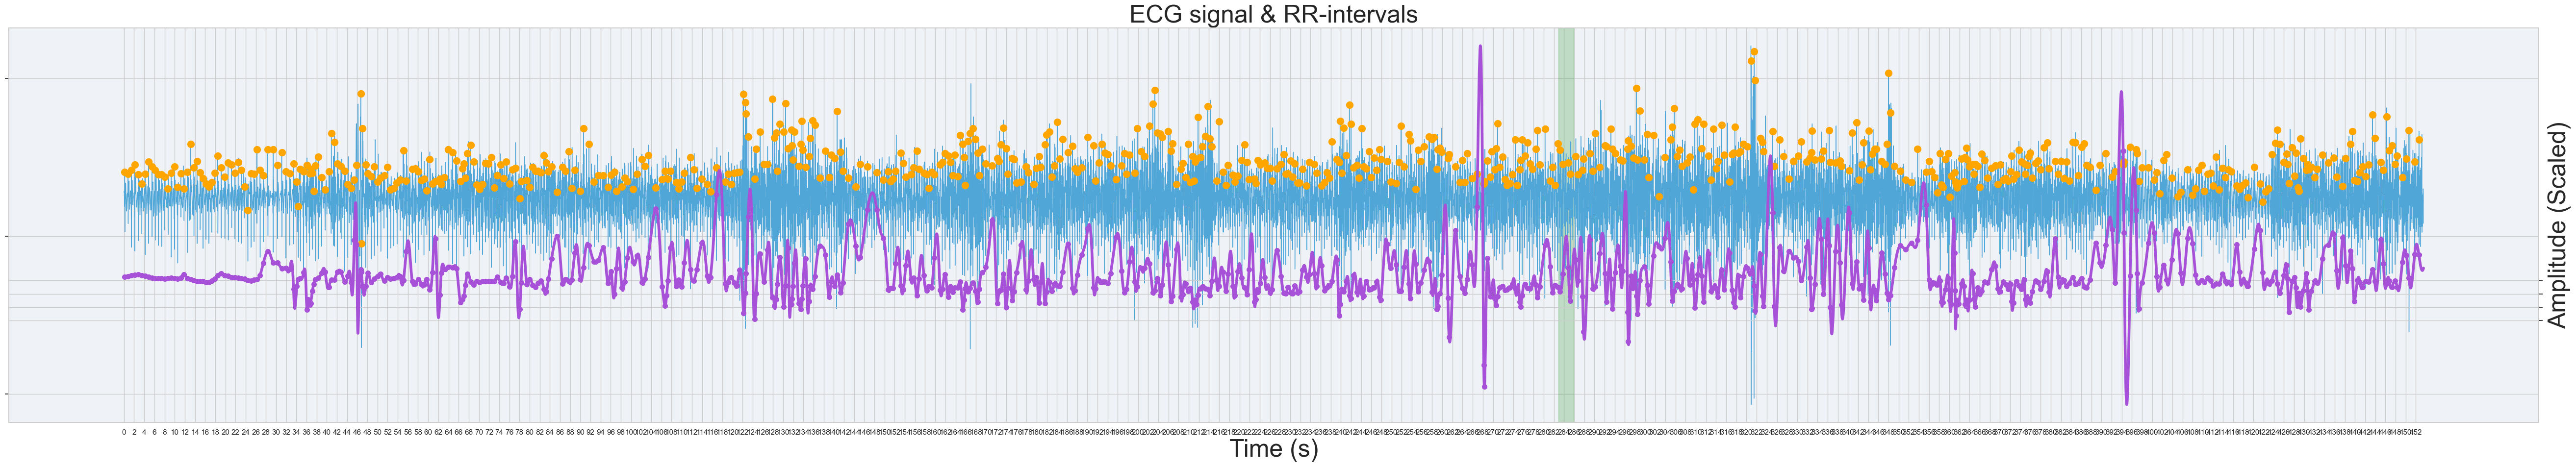

<Figure size 4000x1000 with 0 Axes>

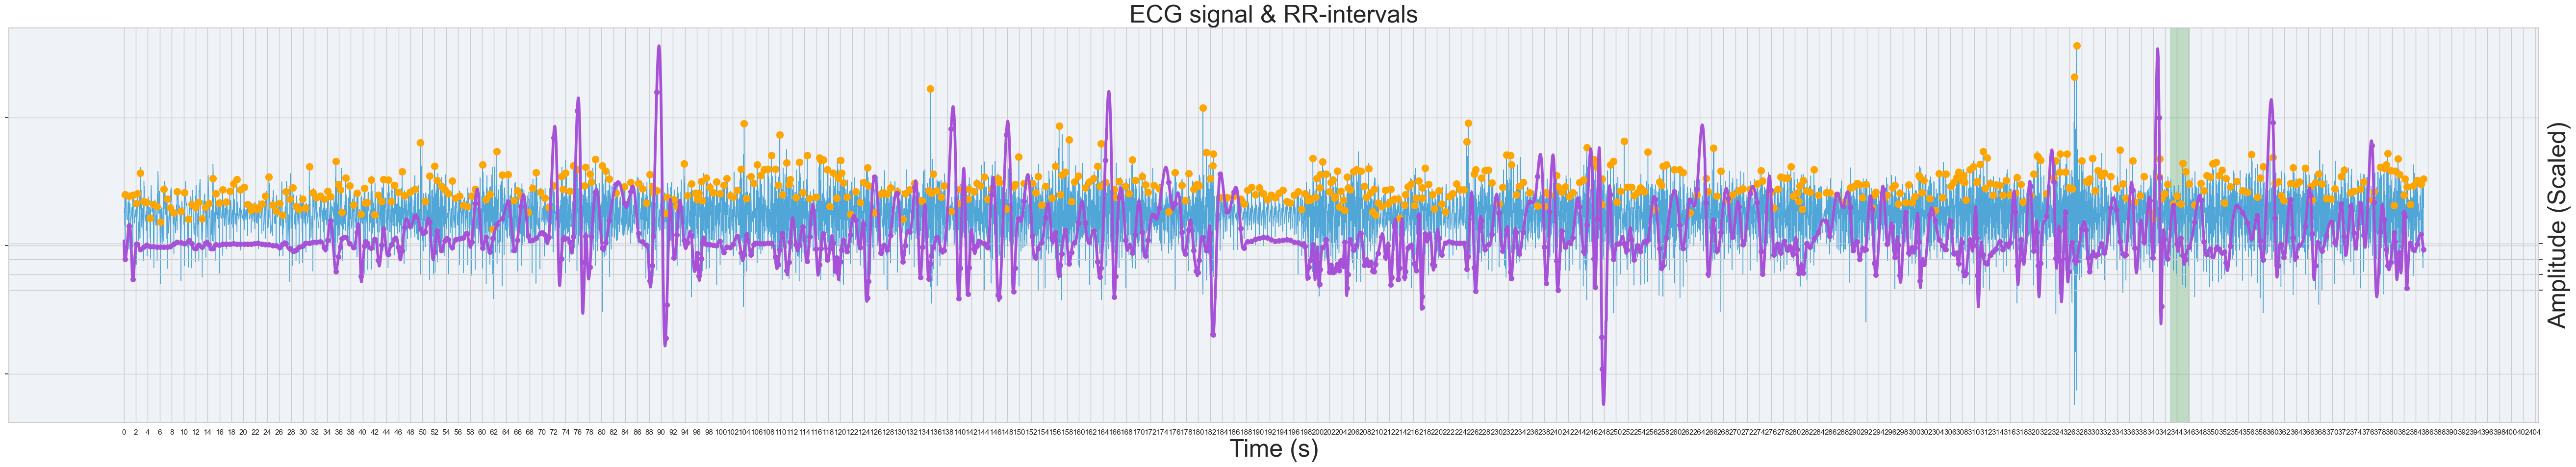

<Figure size 4000x1000 with 0 Axes>

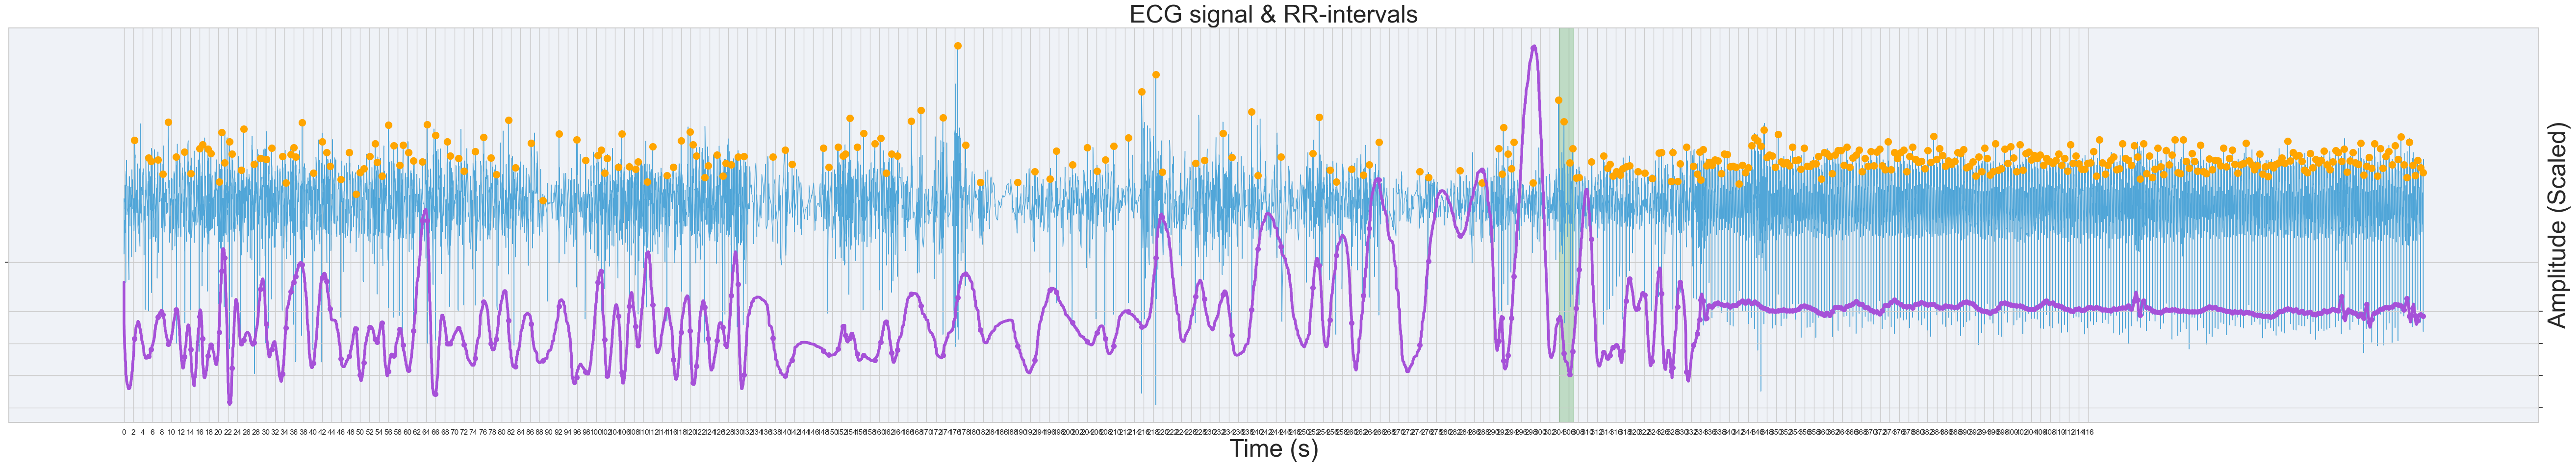

<Figure size 4000x1000 with 0 Axes>

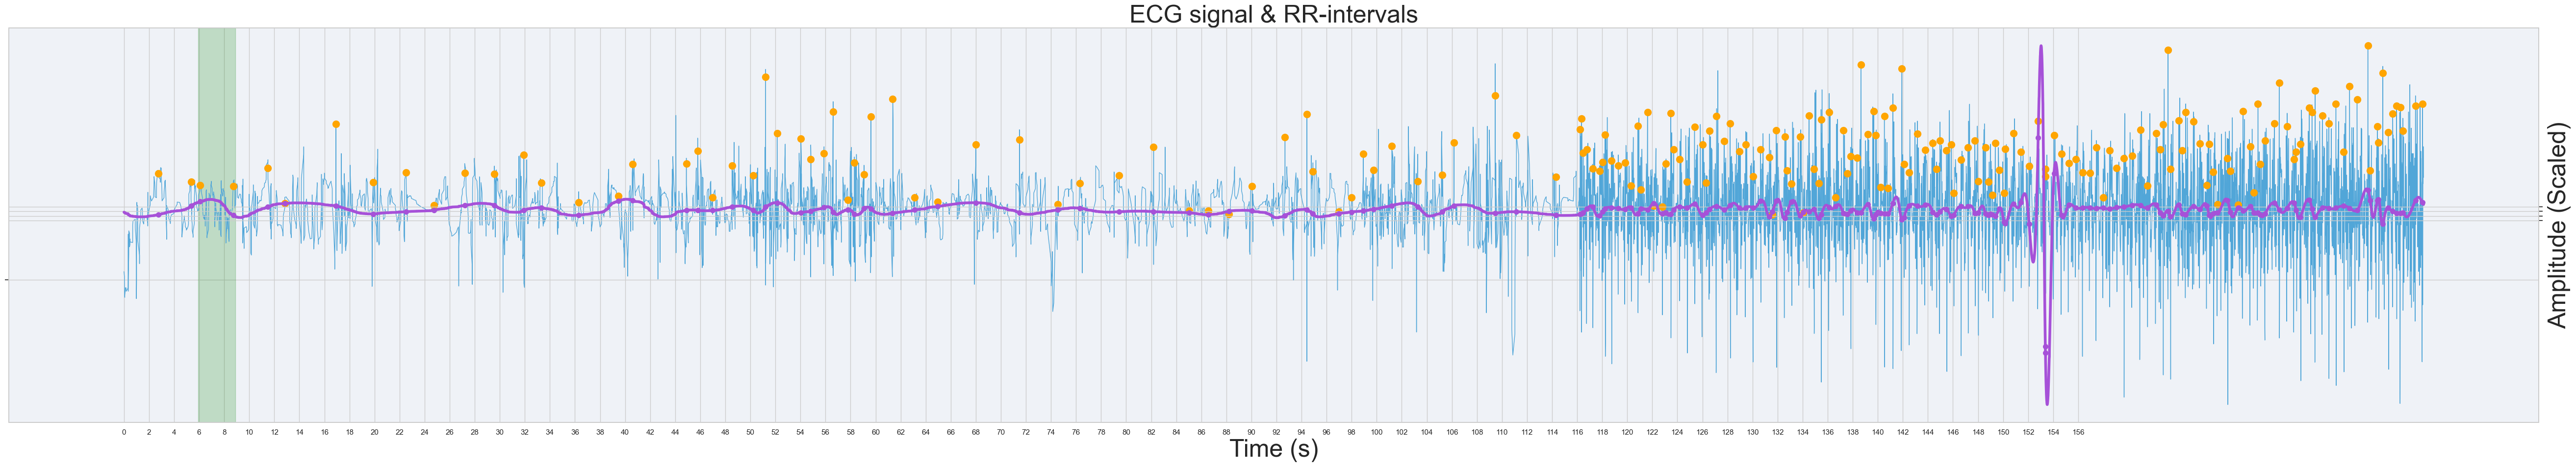

In [97]:
def get_plot_ranges(start=10, end=20, n=5):
    distance = end - start
    for i in np.arange(start, end, np.floor(distance/n)):
        yield (int(i), int(np.minimum(end, np.floor(distance/n) + i)))

plt_font_size = 36
DoP_ID = 0

#additioinal filtering
wavelet = 'db6'  # Daubechies 6 is commonly used for ECG
level = 5  # Decomposition level
threshold_scale = 5.0  # 🔨 Massive threshold

pde_selected_takes_timestamps = [287.0, 347.0, 308.0, 10.0]
# pde_selected_takes_timestamps = [10.0, 20.0, 30.0, 40.0]

def render_sensor_graph(df, times, start_time_index, end_time_index, interval=250):
    # sampfrom = 0
    # sampto = len(times) - 1
    # sampto = 11918
    nr_plots = 1
    trim_division = 1.4
    trim_index_start = 0
    # nr_plots = 6
    # Batch size for animation
    batch_size = 10

    def update_batch(batch_index):
        start = batch_index * batch_size
        end = start + batch_size
        sys.stdout.write("\r \r Progress: {0}%".format(str((start / num_frames)*100)))
        sys.stdout.flush()
        if (channel != 0):
            # update the line plot
            ecg_line.set_xdata(ecg_x[:end])
            ecg_line.set_ydata(ecg_slice_filtered[:end])
            if len(peaks) > 0:
                # anim_ecg_peaks = ecg_x[peaks[peaks < ecg_x_index[start]]]
                anim_ecg_peaks = np.where(peaks < ecg_x_index[start])
                ecg_peaks.set_xdata(ecg_peaks_x[anim_ecg_peaks])
                ecg_peaks.set_ydata(ecg_slice_filtered[peaks[anim_ecg_peaks]])

            # rr_line.set_xdata(ecg_x[:end])
            # rr_line.set_ydata(rr_y_interp[:end])
            # anim_rr_peaks = np.where(peaks[:-1] < ecg_x[start])
            # rr_peaks.set_xdata(rr_x[anim_rr_peaks])
            # rr_peaks.set_ydata(rr_ms[anim_rr_peaks])
        else:
            for i, line in enumerate(acc_slice_filtered):
                ecg_line[i].set_xdata(ecg_x[:end])
                ecg_line[i].set_ydata(line[:end])

        return (ecg_line)

    df_slice = [pd.DataFrame() for _ in range(len(film_durations[jf_id]))]
    masked_ranges = get_masked_ranges(start_time_index, end_time_index, len(times))[:-1]
    masked_from, _ = zip(*masked_ranges)
    masked_from_t = times[list(masked_from)]
    print("DEBUG: ", times[list(masked_from)])
    for take, ranges in enumerate(masked_ranges):
        # start, stop = ranges
        sampfrom, sampto = ranges
        # pde_take_timestamps = [x[1] for i, x in enumerate(pde_selected_takes_timestamps) if x[0][0] == DoP_ID+1 and x[0][2] == take+1]
        # pde_figure_id = [x[2] for i, x in enumerate(pde_selected_takes_timestamps) if x[0][0] == DoP_ID+1 and x[0][2] == take+1]
        print(DoP_ID)
        print(identifiers[DoP_ID])
        pde_take_timestamps = [pde_selected_takes_timestamps[DoP_ID]]
        print(pde_take_timestamps)
        pde_figure_id = identifiers[DoP_ID]
        if (len(pde_take_timestamps) == 0):
            print("len(pde_take_timestamps): ", pde_take_timestamps)
            pass
        else:
            print("DEBUG", DoP_ID+1)
            print("DEBUG", take+1)
            print("DEBUG", pde_figure_id)
            print(masked_from_t[take])
            pde_take_timestamps = np.array(pde_take_timestamps) - masked_from_t[take]
            print("DEBUG", pde_take_timestamps)
        for i, start_stop in enumerate(get_plot_ranges(sampfrom, sampto, nr_plots)):
            if not times[start_stop[0]] <= pde_take_timestamps[0] <= times[start_stop[1]]:
                print("No annotations found")
                pass
            start, stop = start_stop
            # article figure zoom in / annotate
            cond_slice = (df.index >= start) & (df.index < stop)
            ecg_slice = df.heartrate[cond_slice]
            if (current_label != "ACC"):
                ecg_slice = df.heartrate[cond_slice]
                x_slice = ecg_slice
            else:
                x_slice = df.heartrate[cond_slice]
                ecg_slice = [[acc[0],acc[1],acc[2]] for acc in df.heartrate[cond_slice]]
            try:
                # print(times[x_slice.index])
                seconds_per_window = round((times[x_slice.index][-1] - times[x_slice.index][0]) / 1) + 1
            except Exception as e:
                print("Exception", e)
                # continue
                # seconds_per_window = 0
            seconds_per_window = int(seconds_per_window // trim_division)
            x_second_labels = np.arange(0+(i*seconds_per_window),seconds_per_window+(i*seconds_per_window),2)
            print("x_second_labels", x_second_labels)
            # continue
            min_window = 562
            if len(ecg_slice) > min_window:
                # ecg_stats = ecg.ecg(signal=ecg_slice, sampling_rate=1000/4, show=0)
                # ecg_stats = ppg.ppg(signal=ecg_slice, sampling_rate=1000/10, show=0)
                # ecg_stats = acc.acc(signal=ecg_slice, sampling_rate=1000/10, show=0)
                try:
                    if (current_label == "ECG"):
                        ecg_stats = ecg.ecg(signal=ecg_slice, sampling_rate=1000/4, show=0)
                        ecg_slice_filtered = ecg_stats[1] / 1.8 + 1000
                        peaks = ecg_stats[2]
                        # Additional filtering
                        coeffs = pywt.wavedec(ecg_slice_filtered, wavelet, level=level)
                        threshold = threshold_scale * np.median(np.abs(coeffs[-1])) / 0.6745 * np.sqrt(2 * np.log(len(ecg_slice_filtered)))
                        coeffs[1:] = [pywt.threshold(c, threshold, mode='soft') for c in coeffs[1:]]
                        ecg_slice_filtered = pywt.waverec(coeffs, wavelet)[:len(ecg_slice_filtered)]
                    if (current_label == "ACC"):
                        ecg_stats = acc.acc(signal=ecg_slice, sampling_rate=1000/10, interactive=0, show=0)
                        ecg_slice_filtered = ecg_stats[1]
                        df_slice["magnitude"] = ecg_stats[2]
                        df_slice["smoothed"] = df_slice["magnitude"].ewm(alpha=0.25, adjust=False).mean()
                        ecg_slice_filtered = df_slice["smoothed"]

                        plt.plot(times[x_slice.index], ecg_slice_filtered, label=current_label, color="#51A6D8", linewidth=3)
                        plt.show()
                    if (current_label == "EDA"):
                        ecg_stats = eda.eda(signal=ecg_slice, sampling_rate=1000/10, show=0)
                        ecg_slice_filtered = ecg_stats[1]
                        # Extracted features (SCR, SCL, etc.)
                        peaks = ecg_stats[5]
                        onsets = ecg_stats['onsets']
                        edl = ecg_stats['edl']  # Skin conductance level
                        edr = ecg_stats['edr']  # Skin conductance response
                        # if isinstance(peaks, int):
                        #     peaks = [int(digit) for digit in str(peaks)]
                except ValueError as e:
                    print("ValueError", e)
                    ecg_slice_filtered = ecg_slice
                    peaks = []
                    # if (current_label == "EDA"):
                    #     continue
                        # print(len(peaks))
            else:
                print("break")
                break

            try:
                sample_freq = stop/times[stop]
                interval_ms = 2
                # sampled_times = times[cond_slice][::batch_size]
                time_elapsed = np.diff(times[cond_slice][::batch_size]) * 1000
                frames_elapsed = [round(te / (interval_ms*batch_size)) for te in time_elapsed]
                frame_t = []
                for frame, repeat in enumerate(frames_elapsed):
                    # print(frame, repeat)
                    frame_t.extend([frame] * repeat)

                #ecg_x = ecg_slice.index - start
                # ecg_x = x_slice.index - start

                # ECG
                if (current_label == "ECG"):
                    rr = np.diff(peaks)
                    rr_ms = (np.diff(peaks) / interval)*4000
                    rr_x = np.cumsum(rr)+peaks[0]
                    z2 = rr_ms

                    cs = CubicSpline(rr_x, rr_ms)               # Create a cubic spline
                    rr_x_interp = np.linspace(rr_x.min(), rr_x.max(), len(ecg_slice_filtered))  # Dense x-points
                    rr_y_interp = cs(rr_x_interp)
            except IndexError as e:
                print("DEBUG", e)
                continue
                # rr_ms = np.append(rr_ms, rr_ms[-1])

        #ACC
            # if (current_label == "ACC"):
            #     acc_slice_filtered = np.array(ecg_slice_filtered).T

            # plot similarity
            anim_fig = plt.figure(figsize=(40, 10))
            # ax = plt.subplot()
            fig_scale_x = 120 / nr_plots / 1.6
            fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(fig_scale_x // trim_division, 10))#, sharex=True, sharey=True)

            ecg_line = []
            if (current_label == "ECG"):
                plt.title("ECG signal & RR-intervals", fontsize=plt_font_size)
            if (current_label == "EDA"):
                plt.title("EDA Signal & SDR Peaks", fontsize=plt_font_size)
            # plt.legend(loc="upper left", fontsize=20)
            plt.xlabel("Time (s)", fontsize=plt_font_size)
            # plt.ylabel("Amplitude (Scaled)", fontsize=plt_font_size)
            plt.yticks(np.arange(0,3200,800), labels=[], fontsize=plt_font_size)
            if (current_label != "ACC"):
                df_slice[take]['y'] = ecg_slice_filtered
                df_slice[take]['x'] = times[ecg_slice.index] - times[x_slice.index][0]
                ecg_x = df_slice[take]['x']
                ecg_x_index = ecg_slice.index - x_slice.index[0]
                # print(peaks)
                trim_index = int(len(ecg_slice_filtered) // trim_division)
                ecg_line = ax.plot(times[ecg_slice.index][trim_index_start:trim_index] - times[x_slice.index][0], ecg_slice_filtered[trim_index_start:trim_index], label="Filtred ECG" if current_label != "EDA" else "Filtered EDA", color="#51A6D8", linewidth=1 if current_label != "EDA" else 4)[0]
                if len(peaks) > 0:
                    peaks_trimmed = peaks[peaks < trim_index]
                    peaks_trimmed = peaks_trimmed[peaks_trimmed > trim_index_start]
                    ecg_peaks_x = times[peaks+start] - times[x_slice.index][0]
                    ecg_peaks = ax.plot(times[peaks_trimmed+start] - times[x_slice.index][0], ecg_slice_filtered[peaks_trimmed], markersize=10 if current_label != "EDA" else 25, label="R-peak" if current_label != "EDA" else "SCR peak", color="orange", marker="o", linestyle="None")[0]
            if (current_label == "EDA"):
                try:
                    onsets_trimmed = onsets[onsets < trim_index]
                    onsets_trimmed = onsets_trimmed[onsets_trimmed > trim_index_start]
                    rr_line = ax.plot(times[ecg_slice.index][trim_index_start:trim_index] - times[x_slice.index][0], edl[trim_index_start:trim_index], label="SCL", color="green", linewidth=3, alpha=0.5)[0]
                    ecg_onsets = ax.plot(times[onsets_trimmed+start] - times[x_slice.index][0], ecg_slice_filtered[onsets_trimmed], markersize=25, markeredgewidth=6, label="SCR onset", color="red", marker='|', linestyle="None")[0]
                    for onst in onsets_trimmed:  # Every 2 units, from 0 to 10
                        plt.axvline(times[onst+start] - times[x_slice.index][0], color='grey', linestyle='--', alpha=0.5, linewidth=5)
                except Exception as e:
                    print ("DEBUG", e)
                    pass
            if (current_label == "ECG"):
                    ax2 = ax.twinx()
                    rr_line = ax2.plot(times[ecg_slice.index][trim_index_start:trim_index] - times[x_slice.index][0], rr_y_interp[trim_index_start:trim_index], linewidth=4, label="RR intervals", color="#A651D8", markerfacecolor="#A651D8")[0]
                    rr_peaks = ax2.plot(times[peaks_trimmed+start] - times[x_slice.index][0], rr_y_interp[peaks_trimmed], label="_nolegend_", color="#A651D8", linewidth=2, markerfacecolor="#A651D8", markeredgewidth=0, marker="o", markersize=8, linestyle="None")[0]
                    print((times[x_slice.index][-1] - times[x_slice.index][0]) / 1 + 2)
        # triaxial data
            # if (current_label == "ACC"):
            #     plt.plot(times[x_slice.index], ecg_slice_filtered, label=current_label, color="#51A6D8", linewidth=3)
                # plt.plot(times[x_slice.index], (1*df_slice["second_order_diff"]) + 1, label=current_label, color="orange", linewidth=3)
                # plt.ylim(0.9, 1.1)
            # seconds_per_window = 16
            # plt.legend(loc="upper right", fontsize=plt_font_size, bbox_to_anchor=(1.11, 1))
            plt.xlabel("Time (s)", fontsize=plt_font_size)
            plt.xticks(np.arange(0,seconds_per_window,2), labels=x_second_labels, fontsize=plt_font_size)
            if current_label == "ECG":
                plt.ylabel("RR-interval (s)", fontsize=plt_font_size)
                ax2.set_ylabel("Amplitude (Scaled)", fontsize=plt_font_size)
                ax2.set_yticks(np.arange(0,3200,800), labels=[], fontsize=plt_font_size)
                # plt.yticks(np.arange(800,3200,800),labels=np.arange(800,3200,800)/4000, fontsize=plt_font_size)
            if current_label == "EDA":
                yticks = ax.get_yticks()
                plt.ylabel(r"Conductance ($\mu S_{\mathrm{norm}}$)", fontsize=plt_font_size)
                yticks = np.linspace(min(yticks)*0.9, max(yticks)*1.1, 3)
                plt.yticks(yticks, labels=np.linspace(0, 1, 3), fontsize=plt_font_size)
            plt.tight_layout(pad=2.0)
            for i, pde_timestamp in enumerate(pde_take_timestamps):
                print("Annotation found", pde_timestamp)
                print(min(x_second_labels))
                if min(x_second_labels) <= pde_timestamp <= max(x_second_labels):
                    local_x = pde_timestamp - min(x_second_labels)
                    # local_x = local_x - 0.9
                    local_x = local_x - 2.5
                    ax.axvspan(local_x - 1.5, local_x + 1.5, color='green', alpha=0.2)
                    plt.savefig(f"../Output/PDE_Figures/{current_label}/DP_{identifiers[DoP_ID]}_{pde_figure_id[i]}_sync.svg", dpi=150, bbox_inches='tight')
                    # plt.savefig(f"../Output/PDE_Figures/{current_label}/{pde_figure_id[i]}_DP_{identifiers[DoP_ID]}_half.svg", dpi=150, bbox_inches='tight')
                    # plt.savefig(f"../Output/PDE_Figures/{current_label}/{pde_figure_id[i]}_DP_{identifiers[DoP_ID]}_quart.svg", dpi=150, bbox_inches='tight')

            # if len(pde_take_timestamps) == 0:
            #     print("No annotation here")
                # plt.savefig(f"../Output/PDE_Figures/{current_label}/No annotation/DP_{identifiers[DoP_ID]}_{take}_{i}_full.svg", dpi=150, bbox_inches='tight')

            num_frames = len(ecg_slice_filtered)
            # ani = animation.FuncAnimation(fig=anim_fig, func=update_batch, frames=round(num_frames / batch_size), interval=(1000/sample_freq) * batch_size)
            # print(np.where(peaks < ecg_x_index[500]))
            if (False):
                ani = animation.FuncAnimation(fig=anim_fig, func=update_batch, frames=frame_t, interval=interval_ms * batch_size)
                ani.save(filename=f"../Output/Sensor_Graphs_Yilmaz/DP_{identifiers[DoP_ID]}_{start}-{stop}_sync.mp4", writer="ffmpeg")
            # plt.show()
        # break

for jf_id, jf in enumerate(filtered_json_files_list[:]):
    if "Resting" not in jf:
        print(DoP_ID, identifiers[DoP_ID])
        # print(jf)
        # print(f"../Output/Sensor_Grpahs/DP_{identifiers[DoP_ID]}_{start}-{stop}_sync.mp4")
        times, sensors, duration = get_data_from_json(jf_id, dev_id, channel, False)

        start_time_index = [np.where(
            times==min(times, key=lambda x:abs(x-start_time)))[0][0] for start_time in takes_start_time_s[jf_id]]
        # end_time_seconds = np.add(start_times, durations).tolist()
        end_time_index = [np.where(
            times==min(times, key=lambda x:abs(x-end_time)))[0][0] for end_time in film_durations[jf_id]]
        last_end_index = 0
        for ranges in get_masked_ranges(start_time_index, end_time_index, len(times)):
            # print(ranges, last_end_index)
            sensors = zero_until_range(sensors, ranges[0] if ranges[1] != len(times) else len(times), last_end_index)
            last_end_index = ranges[1]
        times = times[:] - takes_start_time_s[jf_id][0]

        df = pd.DataFrame({"index": times, "heartrate": sensors})

        render_sensor_graph(df, times, start_time_index, end_time_index)
        DoP_ID += 1